# Earth2Studio Disaster Replay Demo: Hat Yai Flood — November 2025

**Real Earth2Studio-style inference notebook with Thai executive narrative**

### ภาษาไทย
Notebook นี้เป็นเวอร์ชันสำหรับการสาธิตเชิงบริหารของกรณีน้ำท่วมหาดใหญ่ พฤศจิกายน 2568 โดยยังคง workflow ทางเทคนิคเดิมไว้: โหลด data source, โหลด model, รัน inference, เขียน output, อ่านผลกลับมา และสร้าง visualization จาก output จริงหรือ fallback ที่ระบุชัดเจน

**หมายเหตุด้านความปลอดภัย:** Notebook นี้เป็นงานวิจัยและ demo เท่านั้น ไม่ใช่ระบบพยากรณ์หรือคำเตือนภัยอย่างเป็นทางการสำหรับการตัดสินใจด้านชีวิตและทรัพย์สิน

### English
This notebook demonstrates an Earth2Studio-style AI weather workflow for a retrospective Hat Yai flood replay. It is designed for executive, government, and technical audiences: the technical pipeline remains visible, while each section explains what the output means for flood early warning.

**Safety note:** Research/demo only. Not an official life-safety flood warning system.

# Executive Summary / บทสรุปสำหรับผู้บริหาร

### ภาษาไทย
Notebook นี้เป็นต้นแบบเชิงเทคนิค ไม่ใช่ระบบพยากรณ์ทางการ เป้าหมายคือสาธิตว่า Earth2Studio และ AI weather model สามารถใช้ย้อนรอย วิเคราะห์สัญญาณล่วงหน้า และจำลอง logic การแจ้งเตือนภัยน้ำท่วมหาดใหญ่ช่วง พ.ย. 2568 ได้อย่างไร

สิ่งที่ผู้บริหารควรดู:

1. ระบบดึงข้อมูลและรัน inference ได้จริงหรือไม่
2. สัญญาณฝนสะสมหรือ risk proxy เริ่มสูงเมื่อไร
3. ระบบควรยกระดับคำเตือนเมื่อไร จาก GREEN ไป YELLOW/ORANGE/RED/PURPLE
4. ต้องเชื่อมข้อมูลท้องถิ่นอะไรเพิ่มเพื่อใช้งานจริง เช่น TMD, ThaiWater, radar, rain gauge, water-level sensors, DEM, drainage map
5. จะต่อยอดเป็น **Sovereign AI Flood Watchdog** สำหรับประเทศไทยได้อย่างไร

> **สำหรับผู้บริหาร:**  
> จุดประสงค์ของ notebook นี้ไม่ใช่ให้ดู code เป็นหลัก แต่ให้เห็น end-to-end pipeline ว่า AI weather forecast สามารถถูกแปลงเป็นข้อมูลสนับสนุนการตัดสินใจเรื่องน้ำท่วมได้อย่างไร ตั้งแต่ data/model ไปจนถึงแผนที่ ตาราง และระดับคำเตือน

### English
This is a technical demonstration, not an official forecast. It shows how an Earth2Studio-based AI weather workflow can replay the November 2025 Hat Yai flood case, inspect forecast signals, and translate atmospheric model output into early-warning indicators.

## 0. Case Story / เรื่องเล่าเหตุการณ์

### English
The case focuses on Hat Yai, Songkhla, Thailand during November 2025. The critical monitoring window is 17-28 November 2025, with special attention to 22-26 November when flood escalation risk is expected to be highest. The notebook follows an operational story: load weather data, run AI forecast inference, extract Hat Yai signals, build risk indicators, and convert them into alert levels.

### ภาษาไทย
กรณีศึกษานี้โฟกัสเมืองหาดใหญ่ จ.สงขลา ช่วงเดือนพฤศจิกายน 2568 โดยมองช่วง 17-28 พฤศจิกายนเป็นช่วงเฝ้าระวังสำคัญ และช่วง 22-26 พฤศจิกายนเป็นหน้าต่างที่ระบบควรจับสัญญาณการยกระดับความเสี่ยงอย่างใกล้ชิด

สิ่งที่ notebook พยายามตอบคือ: เกิดอะไรขึ้น, model เห็นสัญญาณอะไร, สัญญาณนั้นควรถูกแปลงเป็นคำเตือนเมื่อไร, และระบบปฏิบัติการจริงต้องเพิ่มข้อมูลท้องถิ่นอะไรอีก

> **สำหรับผู้บริหาร:**  
> น้ำท่วมเมืองไม่ได้เกิดจากฝนวันเดียวเสมอไป แต่เกิดจากฝนสะสม ลุ่มน้ำ upstream คลองหลัก คอขวดการระบายน้ำ และ exposure ของเมือง ดังนั้นระบบเตือนภัยต้องดูทั้งสัญญาณอากาศและข้อมูลพื้นที่จริงร่วมกัน

## 1. Imports and Environment Check / ตรวจสอบสภาพแวดล้อม

### English
This section imports Python, Earth2Studio, PyTorch, xarray, matplotlib, and optional Cartopy dependencies. It checks whether CUDA/GPU, Earth2Studio, and plotting libraries are available before running the workflow.

### ภาษาไทย
ส่วนนี้ตรวจว่าเครื่องพร้อมรัน pipeline หรือไม่ เช่น Python version, PyTorch, CUDA/GPU, Earth2Studio และ library สำหรับ plot แผนที่ ถ้าบาง dependency ไม่พร้อม notebook จะไม่หยุดทันที แต่จะบันทึกสถานะไว้เพื่อเลือก path ที่เหมาะสม

> **สำหรับผู้บริหาร:**  
> ส่วนนี้ตอบคำถามว่า infrastructure พร้อมสำหรับ AI weather inference หรือไม่ หาก GPU และ Earth2Studio พร้อม ระบบสามารถต่อยอดเป็น workflow ที่รันตามรอบ forecast ได้จริง หากไม่พร้อม notebook จะแสดง fallback mode ชัดเจน ไม่แอบอ้างว่าเป็นผลพยากรณ์จริง

In [1]:
from __future__ import annotations

import json
import os
import sys
import traceback
from collections import OrderedDict
from datetime import datetime
from pathlib import Path
from typing import Any

import numpy as np
import pandas as pd
import xarray as xr

try:
    from IPython.display import Image, Markdown, display
except Exception:
    display = print
    Image = None
    Markdown = lambda text: text

try:
    from dotenv import load_dotenv

    load_dotenv()
except Exception:
    pass

try:
    import matplotlib.dates as mdates
    import matplotlib.pyplot as plt

    HAS_MATPLOTLIB = True
except Exception as exc:
    HAS_MATPLOTLIB = False
    print(f"Matplotlib unavailable: {exc}")

try:
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature

    HAS_CARTOPY = True
except Exception:
    HAS_CARTOPY = False

try:
    import torch

    HAS_TORCH = True
    HAS_GPU = bool(torch.cuda.is_available())
except Exception:
    torch = None
    HAS_TORCH = False
    HAS_GPU = False

try:
    from loguru import logger

    logger.remove()
    logger.add(sys.stderr, level="INFO")
except Exception:
    logger = None

try:
    from earth2studio.data import ARCO, GFS, NCAR_ERA5
    from earth2studio.io import ZarrBackend
    from earth2studio.models.px import DLWP, FCN, FCN3, Persistence, SFNO
    from earth2studio.perturbation import SphericalGaussian
    from earth2studio.run import deterministic, ensemble

    HAS_EARTH2STUDIO = True
except Exception as exc:
    HAS_EARTH2STUDIO = False
    EARTH2STUDIO_IMPORT_ERROR = repr(exc)
    print("Earth2Studio import failed:", EARTH2STUDIO_IMPORT_ERROR)

if HAS_MATPLOTLIB:
    plt.style.use("seaborn-v0_8-whitegrid")
    plt.rcParams.update({"figure.figsize": (11, 5), "savefig.dpi": 160})

print("Environment summary")
print("-------------------")
print("Python:", sys.version.split()[0])
print("Earth2Studio available:", HAS_EARTH2STUDIO)
print("Torch available:", HAS_TORCH)
if HAS_TORCH:
    print("Torch:", torch.__version__)
    print("CUDA available:", HAS_GPU)
    if HAS_GPU:
        print("GPU:", torch.cuda.get_device_name(0))
print("Cartopy available:", HAS_CARTOPY)

/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/torch/cuda/__init__.py:65: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml  # type: ignore[import]
/home/siamai/earth2studio-project/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Warp DeprecationWarning: The symbol `warp.context.Device` will soon be removed from the public API. Use `warp.Device` instead.
CuPy distance computation test failed with error: cuVS >= 24.12 or pylibraft < 24.12 should be installed to use this feature
Environment summary
-------------------
Python: 3.13.13
Earth2Studio available: True
Torch available: True
Torch: 2.10.0+cu130
CUDA available: True
GPU: NVIDIA GB10
Cartopy available: True


### ภาษาไทย: การตีความผล Environment Check

ตาราง/ข้อความจาก cell ข้างบนแสดงว่าเครื่องสามารถ import Earth2Studio และ PyTorch ได้หรือไม่ รวมถึง CUDA ใช้งานได้หรือไม่ จุดที่ควรดูคือ `Earth2Studio available`, `CUDA available`, และชื่อ GPU

ข้อจำกัด: การมี GPU ไม่ได้แปลว่าระบบพร้อมใช้งานจริงทันที ยังต้องมี model weights, data access, storage, monitoring, และกระบวนการ approval สำหรับคำเตือนภัย

## 2. Case Configuration / ตั้งค่ากรณีศึกษา

### English
This section defines the Hat Yai location, bounding box, forecast initialization dates, forecast length, output variables, and output folders. It keeps the domain small for fast plotting while following the Earth2Studio global-model inference pattern.

### ภาษาไทย
ส่วนนี้กำหนดพิกัดหาดใหญ่ ขอบเขตพื้นที่ศึกษา วันที่เริ่มพยากรณ์ ช่วงเวลาวิกฤต ตัวแปรที่ต้องการดู และ folder สำหรับบันทึก output การตั้งค่านี้ทำให้ทุกคนเห็นตรงกันว่า demo กำลังวิเคราะห์พื้นที่และช่วงเวลาใด

> **สำหรับผู้บริหาร:**  
> การกำหนดพื้นที่และวันที่อย่างชัดเจนสำคัญมาก เพราะการเตือนภัยต้องตอบได้ว่า “เตือนที่ไหน”, “เตือนช่วงเวลาใด”, และ “หลักฐานมาจาก forecast รอบไหน”

In [2]:
CASE_NAME = "hatyai_flood_nov2025_real"
CENTER_LAT = 7.008
CENTER_LON = 100.474
BBOX = {"lat_min": 5.5, "lat_max": 8.5, "lon_min": 99.0, "lon_max": 102.0}

HIST_START = pd.Timestamp("2025-11-01 00:00")
HIST_END = pd.Timestamp("2025-11-30 23:59")
CRITICAL_START = pd.Timestamp("2025-11-17 00:00")
CRITICAL_END = pd.Timestamp("2025-11-28 23:59")
MAIN_ESCALATION_START = pd.Timestamp("2025-11-22 00:00")
MAIN_ESCALATION_END = pd.Timestamp("2025-11-26 23:59")

INIT_TIMES = pd.to_datetime(
    [
        "2025-11-17 00:00",
        "2025-11-19 00:00",
        "2025-11-21 00:00",
        "2025-11-23 00:00",
        "2025-11-24 00:00",
    ]
)

# Default real run: 72 hours because 24h and 72h risk-proxy windows are required.
# For a full 10-day replay, set HATYAI_REAL_NSTEPS=40 before running the notebook.
N_STEPS = int(os.environ.get("HATYAI_REAL_NSTEPS", "12"))
MAX_REAL_INITS = int(os.environ.get("HATYAI_MAX_REAL_INITS", str(len(INIT_TIMES))))
RUN_INIT_TIMES = INIT_TIMES[:MAX_REAL_INITS]

RUN_REAL_ENSEMBLE = os.environ.get("HATYAI_RUN_REAL_ENSEMBLE", "1").lower() in {"1", "true", "yes"}
ENSEMBLE_MEMBERS = int(os.environ.get("HATYAI_ENSEMBLE_MEMBERS", "2"))
ENSEMBLE_NSTEPS = int(os.environ.get("HATYAI_ENSEMBLE_NSTEPS", str(min(4, N_STEPS))))

OUTPUT_DIR = Path("outputs") / "hatyai_flood_nov2025_real"
FORECAST_DIR = OUTPUT_DIR / "forecast"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"
for path in [FORECAST_DIR, FIGURE_DIR, TABLE_DIR]:
    path.mkdir(parents=True, exist_ok=True)

OUTPUT_VARIABLES = np.array(["t2m", "msl", "tcwv", "u10m", "v10m", "u850", "v850", "q850", "z500"])
ENSEMBLE_OUTPUT_VARIABLES = np.array(["t2m", "msl", "tcwv", "u10m", "v10m", "u850", "v850", "q850"])
OUTPUT_COORDS = OrderedDict(
    {
        "variable": OUTPUT_VARIABLES,
        "lat": np.arange(BBOX["lat_max"], BBOX["lat_min"] - 0.001, -0.25),
        "lon": np.arange(BBOX["lon_min"], BBOX["lon_max"] + 0.001, 0.25),
    }
)
ENSEMBLE_OUTPUT_COORDS = OrderedDict(
    {
        "variable": ENSEMBLE_OUTPUT_VARIABLES,
        "lat": OUTPUT_COORDS["lat"],
        "lon": OUTPUT_COORDS["lon"],
    }
)

print("Case:", CASE_NAME)
print("Initialization dates:", [str(t) for t in RUN_INIT_TIMES])
print("N_STEPS:", N_STEPS, "=> hours:", N_STEPS * 6)
print("Output:", OUTPUT_DIR)

Case: hatyai_flood_nov2025_real
Initialization dates: ['2025-11-17 00:00:00', '2025-11-19 00:00:00', '2025-11-21 00:00:00', '2025-11-23 00:00:00', '2025-11-24 00:00:00']
N_STEPS: 12 => hours: 72
Output: outputs/hatyai_flood_nov2025_real


## Execution Modes / โหมดการทำงานของ Notebook

### English
The notebook makes the execution mode visible instead of pretending every run is operational:

- **REAL_EARTH2STUDIO_INFERENCE**: Earth2Studio-compatible model and data source loaded successfully, and real inference was executed.
- **REAL_SAMPLE_DATASET**: A real cached/sample dataset or example-derived dataset was used, but the notebook may not have run a fresh operational model forecast.
- **SYNTHETIC_FALLBACK**: Generated demo data was used because model/data access was unavailable. Useful for presentation structure, but not a forecast.

### ภาษาไทย
Notebook นี้จะแสดงแหล่งที่มาของผลลัพธ์อย่างโปร่งใส:

- **REAL_EARTH2STUDIO_INFERENCE** หมายถึงโหลด model และ data source ที่เข้ากับ Earth2Studio ได้สำเร็จ และรัน inference จริง
- **REAL_SAMPLE_DATASET** หมายถึงใช้ dataset จริงแบบ sample/cache/example แต่ไม่ได้ยืนยันว่าเป็น forecast ใหม่เต็มรูปแบบ
- **SYNTHETIC_FALLBACK** หมายถึงใช้ข้อมูลที่สร้างขึ้นเพื่อ demo เท่านั้น ห้ามตีความเป็นคำพยากรณ์หรือคำเตือนภัยจริง

> **สำหรับผู้บริหาร:**  
> ให้ดูค่า `INFERENCE_MODE` ใน summary และ metadata ทุกครั้งก่อนตีความกราฟ หากเป็น `SYNTHETIC_FALLBACK` กราฟมีประโยชน์เพื่ออธิบายระบบ แต่ไม่ใช้ตัดสินใจเชิงปฏิบัติการ

## 3. Earth2Studio Data Source Loading / โหลดแหล่งข้อมูลจริง

### English
This section follows the official Earth2Studio pattern by trying `GFS` first, then other supported sources if needed. The notebook requests real variables at the configured initialization dates and records any data-source error.

### ภาษาไทย
ส่วนนี้พยายามโหลด data source จริงในรูปแบบ Earth2Studio โดยเริ่มจาก GFS เพราะเป็นแหล่งข้อมูล forecast operational ที่เกี่ยวข้องกับการเตือนภัยล่วงหน้า หากโหลดไม่ได้จะบันทึกเหตุผลไว้และค่อย fallback ตามลำดับ

> **สำหรับผู้บริหาร:**  
> ส่วนนี้ตอบว่า pipeline เชื่อมต่อข้อมูลอากาศจริงได้หรือไม่ ในระบบปฏิบัติการจริงควรเชื่อมหลายแหล่ง เช่น GFS, ERA5, TMD, radar, satellite rainfall และ rain gauge เพื่อให้ระบบไม่พังเมื่อแหล่งใดแหล่งหนึ่งมีปัญหา

In [3]:
data_source_errors: list[str] = []
data = None
DATA_SOURCE_NAME = None
inspection_da = None
inspection_variables = ["t2m", "msl", "u10m", "v10m", "tcwv"]

if HAS_EARTH2STUDIO:
    for source_name, source_factory in [
        ("GFS", lambda: GFS(cache=True, verbose=False, async_timeout=600)),
        ("ARCO", lambda: ARCO(cache=True, verbose=False, async_timeout=600)),
        ("NCAR_ERA5", lambda: NCAR_ERA5(cache=True, verbose=False, async_timeout=600)),
    ]:
        try:
            candidate = source_factory()
            # Direct datasource call returns an xarray.DataArray.
            inspection_da = candidate([RUN_INIT_TIMES[0].to_pydatetime()], inspection_variables)
            data = candidate
            DATA_SOURCE_NAME = source_name
            print(f"Selected data source: {DATA_SOURCE_NAME}")
            break
        except Exception as exc:
            reason = f"{source_name} failed: {type(exc).__name__}: {exc}"
            data_source_errors.append(reason)
            print(reason)

if data is None:
    print("No real Earth2Studio data source was available.")
    print("\n".join(data_source_errors))

2026-04-26 22:52:07.042 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 0-999270
2026-04-26 22:52:07.090 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 418561852-946676
2026-04-26 22:52:07.102 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 413135613-876489
2026-04-26 22:52:07.114 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 417594022-967830
2026-04-26 22:52:07.125 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 425313319-1189406
Selected data source: GFS


### ภาษาไทย: การตีความผล Data Source Loading

ผลลัพธ์จาก cell นี้จะแสดงชื่อ data source ที่เลือกใช้ เช่น `GFS` หรือ error ของแต่ละแหล่งข้อมูล ถ้าเห็นว่า GFS โหลดตัวแปรสำคัญได้ แปลว่า notebook มีข้อมูลจริงสำหรับเริ่ม workflow

ข้อจำกัด: GFS เป็น global forecast ไม่ใช่ข้อมูลระดับคลองหรือเมืองโดยตรง จึงต้องเชื่อมข้อมูลฝนจริง ระดับน้ำ และแผนที่ระบายน้ำในขั้น production

## 4. Dataset Inspection / ตรวจสอบ Dataset

### English
This section inspects the selected dataset: dimensions, coordinates, available variables, time range, spatial resolution, and whether the Hat Yai bounding box is inside the domain. It also selects the nearest grid point to Hat Yai.

### ภาษาไทย
ส่วนนี้เป็นการตรวจสอบคุณภาพและขอบเขตของข้อมูลก่อนรัน inference ว่าข้อมูลมีตัวแปรอะไรบ้าง ครอบคลุมพื้นที่หาดใหญ่หรือไม่ ความละเอียดเชิงพื้นที่ประมาณเท่าไร และ grid point ที่ใกล้หาดใหญ่ที่สุดอยู่ตรงไหน

> **สำหรับผู้บริหาร:**  
> Dataset inspection คือการควบคุมคุณภาพเบื้องต้น ถ้าข้อมูลไม่ครอบคลุมพื้นที่หรือไม่มีตัวแปรสำคัญ ผลวิเคราะห์ downstream จะไม่น่าเชื่อถือ แม้ model จะรันสำเร็จก็ตาม

In [4]:
def lon_to_360(lon: float | np.ndarray) -> float | np.ndarray:
    """Convert longitude to 0-360 convention."""
    return np.mod(lon, 360.0)


def summarize_dataarray_domain(da: xr.DataArray) -> dict[str, Any]:
    """Summarize a real Earth2Studio data source sample."""
    lat = da["lat"].values
    lon = da["lon"].values
    lat_res = float(np.nanmedian(np.abs(np.diff(lat))))
    lon_res = float(np.nanmedian(np.abs(np.diff(lon))))
    bbox_inside = (
        BBOX["lat_min"] >= float(np.nanmin(lat))
        and BBOX["lat_max"] <= float(np.nanmax(lat))
        and lon_to_360(BBOX["lon_min"]) >= float(np.nanmin(lon_to_360(lon)))
        and lon_to_360(BBOX["lon_max"]) <= float(np.nanmax(lon_to_360(lon)))
    )
    nearest = da.sel(lat=CENTER_LAT, lon=lon_to_360(CENTER_LON), method="nearest")
    return {
        "dims": dict(da.sizes),
        "coords": list(da.coords),
        "variables": list(da["variable"].values) if "variable" in da.coords else [],
        "time_range": (str(pd.to_datetime(da["time"].values).min()), str(pd.to_datetime(da["time"].values).max())),
        "lat_range": (float(np.nanmin(lat)), float(np.nanmax(lat))),
        "lon_range": (float(np.nanmin(lon)), float(np.nanmax(lon))),
        "spatial_resolution_deg": (lat_res, lon_res),
        "hat_yai_bbox_inside": bool(bbox_inside),
        "nearest_grid_point": {
            "lat": float(nearest["lat"].values),
            "lon": float(nearest["lon"].values),
        },
    }


if inspection_da is not None:
    dataset_summary = summarize_dataarray_domain(inspection_da)
    print(json.dumps(dataset_summary, indent=2))
    inspection_ds = inspection_da.to_dataset(dim="variable")
    sample_path = FORECAST_DIR / "real_data_source_inspection_sample.zarr"
    inspection_ds.to_zarr(sample_path, mode="w")
    print("Saved real datasource inspection sample:", sample_path)
else:
    dataset_summary = {"error": "No real data source sample available"}

{
  "dims": {
    "time": 1,
    "variable": 5,
    "lat": 721,
    "lon": 1440
  },
  "coords": [
    "time",
    "lead_time",
    "variable",
    "lat",
    "lon"
  ],
  "variables": [
    "t2m",
    "msl",
    "u10m",
    "v10m",
    "tcwv"
  ],
  "time_range": [
    "2025-11-17 00:00:00",
    "2025-11-17 00:00:00"
  ],
  "lat_range": [
    -90.0,
    90.0
  ],
  "lon_range": [
    0.0,
    359.75
  ],
  "spatial_resolution_deg": [
    0.25,
    0.25
  ],
  "hat_yai_bbox_inside": true,
  "nearest_grid_point": {
    "lat": 7.0,
    "lon": 100.5
  }
}
Saved real datasource inspection sample: outputs/hatyai_flood_nov2025_real/forecast/real_data_source_inspection_sample.zarr


### ภาษาไทย: การตีความตาราง/ข้อความ Dataset Inspection

ข้อมูลที่พิมพ์ออกมาจะบอก `dimensions`, `coordinates`, `available variables`, `time range`, `spatial resolution` และ nearest grid point ของหาดใหญ่

คอลัมน์/ค่าที่ควรดู:

- `available variables`: มีตัวแปร moisture, wind, pressure ที่ใช้ทำ risk proxy หรือไม่
- `time range`: ครอบคลุมวันที่ initialization หรือไม่
- `spatial resolution`: ละเอียดพอสำหรับ regional signal หรือไม่
- nearest grid point: อยู่ใกล้พิกัดหาดใหญ่เพียงใด

ข้อจำกัด: grid ของ global model ยังหยาบเกินไปสำหรับ urban flooding จึงต้อง downscale และเชื่อม drainage/DEM เพิ่มเมื่อนำไปใช้งานจริง

## 5. Prognostic Model Loading / โหลด AI Weather Model

### English
This section tries to load a real Earth2Studio prognostic model. The preferred model is FCN3/FourCastNet3, with fallbacks to other Earth2Studio-compatible models if available.

### ภาษาไทย
ส่วนนี้โหลด AI weather model จริงผ่าน Earth2Studio โดยให้ FCN3 เป็นตัวเลือกแรก หากโหลดได้สำเร็จ notebook จะสามารถรัน inference จริงจาก initial condition ไปเป็น forecast output ได้

> **สำหรับผู้บริหาร:**  
> Model loading คือจุดที่แยก demo แบบ static ออกจาก AI weather pipeline จริง หาก model โหลดและรันได้ เราสามารถต่อยอดให้ระบบรันตามรอบข้อมูลใหม่ได้ แต่ต้องมีการ validate กับเหตุการณ์จริงและหน่วยงานเจ้าของข้อมูลก่อนใช้เตือนภัยจริง

In [5]:
model = None
MODEL_NAME = None
model_load_errors: list[str] = []

if HAS_EARTH2STUDIO:
    for model_name, model_cls in [("FCN3", FCN3), ("FCN", FCN), ("DLWP", DLWP), ("SFNO", SFNO)]:
        try:
            package = model_cls.load_default_package()
            model = model_cls.load_model(package)
            MODEL_NAME = model_name
            print(f"Selected model: {MODEL_NAME}")
            input_vars = list(model.input_coords()["variable"])
            print("Input variable count:", len(input_vars))
            print("First 20 input variables:", input_vars[:20])
            break
        except Exception as exc:
            reason = f"{model_name} failed: {type(exc).__name__}: {exc}"
            model_load_errors.append(reason)
            print(reason)

if model is None:
    print("No pretrained prognostic model loaded.")
    print("\n".join(model_load_errors))

Selected model: FCN3
Input variable count: 72
First 20 input variables: ['u10m', 'v10m', 'u100m', 'v100m', 't2m', 'msl', 'tcwv', 'u50', 'u100', 'u150', 'u200', 'u250', 'u300', 'u400', 'u500', 'u600', 'u700', 'u850', 'u925', 'u1000']


### ภาษาไทย: การตีความผล Model Loading

ให้ดูค่า `Selected model` และ error list หากมี ถ้า model เป็น `FCN3` และโหลดสำเร็จ แปลว่า workflow ใช้ Earth2Studio prognostic model จริง

ข้อจำกัด: ใน environment นี้ FCN3 ไม่มี precipitation output โดยตรง จึงต้องใช้ตัวแปร moisture/wind/pressure เพื่อสร้าง risk proxy และระบุชัดเจนว่าไม่ใช่ฝนจริง

## 6. Deterministic Forecast Inference with ZarrBackend / รัน Forecast แบบ Deterministic

### English
This section runs the core Earth2Studio workflow: instantiate a `ZarrBackend`, call `earth2studio.run.deterministic`, write forecast output to Zarr, and record per-initialization status.

### ภาษาไทย
ส่วนนี้คือแกนหลักของ notebook เพราะเป็นการรัน inference จริง: ดึง initial condition จาก data source, ส่งเข้า model, สร้าง forecast หลาย lead time, และบันทึก output ลง Zarr เพื่อเปิดดู/plot ต่อได้

> **สำหรับผู้บริหาร:**  
> ส่วนนี้พิสูจน์ว่า pipeline ไม่ได้วาดกราฟจากค่าคงที่ แต่สร้าง forecast output ที่ตรวจสอบย้อนกลับได้ ทุก forecast ควรมี log ว่ารันเมื่อไร ใช้ model/data อะไร และเขียนไฟล์ output ที่ใด

In [6]:
def init_label(init_time: pd.Timestamp) -> str:
    """Compact initialization label for filenames."""
    return pd.Timestamp(init_time).strftime("%Y%m%d%H")


def open_forecast_dataset(path: Path) -> xr.Dataset:
    """Open a Zarr forecast dataset."""
    return xr.open_zarr(path)


deterministic_records: list[dict[str, Any]] = []
deterministic_paths: list[Path] = []
real_inference_errors: list[str] = []
INFERENCE_MODE = "UNSET"

if model is not None and data is not None:
    for init_time in RUN_INIT_TIMES:
        forecast_path = FORECAST_DIR / f"deterministic_{MODEL_NAME}_{DATA_SOURCE_NAME}_{init_label(init_time)}.zarr"
        try:
            chunks = {"time": 1, "lead_time": 1}
            io = ZarrBackend(file_name=str(forecast_path), chunks=chunks, backend_kwargs={"overwrite": True})
            io = deterministic(
                [init_time.to_pydatetime()],
                N_STEPS,
                model,
                data,
                io,
                output_coords=OUTPUT_COORDS,
                device=torch.device("cuda" if HAS_GPU else "cpu") if HAS_TORCH else None,
                verbose=True,
            )
            deterministic_paths.append(forecast_path)
            deterministic_records.append(
                {
                    "init_time": init_time,
                    "path": str(forecast_path),
                    "status": "success",
                    "model": MODEL_NAME,
                    "data_source": DATA_SOURCE_NAME,
                }
            )
        except Exception as exc:
            reason = f"deterministic {init_time} failed: {type(exc).__name__}: {exc}"
            real_inference_errors.append(reason)
            deterministic_records.append(
                {
                    "init_time": init_time,
                    "path": str(forecast_path),
                    "status": "failed",
                    "model": MODEL_NAME,
                    "data_source": DATA_SOURCE_NAME,
                    "reason": reason,
                }
            )
            print(reason)
            print(traceback.format_exc(limit=3))

if deterministic_paths:
    INFERENCE_MODE = "REAL_EARTH2STUDIO_INFERENCE"
else:
    print("No deterministic real inference path succeeded.")

pd.DataFrame(deterministic_records).to_csv(TABLE_DIR / "deterministic_run_log.csv", index=False)
pd.DataFrame(deterministic_records)

2026-04-26 22:52:35.165 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 22:52:35.165 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-04-26 22:52:35.425 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 202149609-750575
2026-04-26 22:52:35.449 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 171938794-1139900
2026-04-26 22:52:35.462 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 360428183-1238033
2026-04-26 22:52:35.474 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 417594022-967830
2026-04-26 22:52:35.484 | DEBUG    | earth2studio.data.gfs:fetch_array:386 -

Running inference: 100%|██████████| 13/13 [01:06<00:00,  5.11s/it]


2026-04-26 22:53:42.864 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
2026-04-26 22:53:42.869 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 22:53:42.869 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-04-26 22:53:42.901 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251119/00/atmos/gfs.t00z.pgrb2.0p25.f000 205060324-1186506
2026-04-26 22:53:42.911 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251119/00/atmos/gfs.t00z.pgrb2.0p25.f000 263294380-559894
2026-04-26 22:53:42.920 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251119/00/atmos/gfs.t00z.pgrb2.0p25.f000 426729823-1199214
2026-04-26 22:53:42.927 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251119/00/atmos/gfs.t00z.pgrb2.0p25.f000

Running inference: 100%|██████████| 13/13 [01:02<00:00,  4.84s/it]


2026-04-26 22:54:46.589 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
2026-04-26 22:54:46.603 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 22:54:46.603 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-04-26 22:54:46.642 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/00/atmos/gfs.t00z.pgrb2.0p25.f000 293194775-748953
2026-04-26 22:54:46.651 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/00/atmos/gfs.t00z.pgrb2.0p25.f000 231230158-1132746
2026-04-26 22:54:46.661 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/00/atmos/gfs.t00z.pgrb2.0p25.f000 181865543-967604
2026-04-26 22:54:46.670 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251121/00/atmos/gfs.t00z.pgrb2.0p25.f000 

...

Running inference: 100%|██████████| 13/13 [01:03<00:00,  4.91s/it]


2026-04-26 22:56:55.580 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete
2026-04-26 22:56:55.584 | INFO     | earth2studio.run:deterministic:78 - Running simple workflow!
2026-04-26 22:56:55.584 | INFO     | earth2studio.run:deterministic:85 - Inference device: cuda
2026-04-26 22:56:55.616 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251124/00/atmos/gfs.t00z.pgrb2.0p25.f000 269544071-1175471
2026-04-26 22:56:55.635 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251124/00/atmos/gfs.t00z.pgrb2.0p25.f000 348766761-561026
2026-04-26 22:56:55.644 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251124/00/atmos/gfs.t00z.pgrb2.0p25.f000 179471148-957713
2026-04-26 22:56:55.655 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251124/00/atmos/gfs.t00z.pgrb2.0p25.f000 

Running inference: 100%|██████████| 13/13 [01:04<00:00,  4.94s/it]

2026-04-26 22:58:00.639 | SUCCESS  | earth2studio.run:deterministic:151 - 
Inference complete


,init_time,path,status,model,data_source
0,2025-11-17,outputs/hatyai_flood_nov2025_real/forecast/det...,success,FCN3,GFS
1,2025-11-19,outputs/hatyai_flood_nov2025_real/forecast/det...,success,FCN3,GFS
2,2025-11-21,outputs/hatyai_flood_nov2025_real/forecast/det...,success,FCN3,GFS
3,2025-11-23,outputs/hatyai_flood_nov2025_real/forecast/det...,success,FCN3,GFS
4,2025-11-24,outputs/hatyai_flood_nov2025_real/forecast/det...,success,FCN3,GFS


### ภาษาไทย: การตีความผล Deterministic Inference

ผลลัพธ์จะบอกว่าแต่ละ initialization date รันสำเร็จหรือไม่ และบันทึก Zarr output ไว้ที่ใด ถ้าเห็นหลายวันที่สำเร็จ แปลว่าสามารถเปรียบเทียบ warning lead time จาก forecast หลายรอบได้

ข้อจำกัด: deterministic forecast เป็น forecast เส้นเดียว ยังไม่สะท้อนความไม่แน่นอนเต็มรูปแบบ จึงควรใช้ ensemble เพิ่มในการปฏิบัติการจริง

## 7. Fallback Dataset Construction / สร้าง Fallback เมื่อข้อมูลหรือ Model ไม่พร้อม

### English
Real inference is attempted first. Fallback logic is only used if model/data access fails. The notebook clearly labels whether the result is real inference, a real sample dataset, or synthetic fallback.

### ภาษาไทย
ส่วนนี้เป็น safety net ของ notebook เพื่อให้ demo ยังรันได้แม้ internet, credential, model weights หรือ dependency บางอย่างมีปัญหา แต่จะไม่แอบอ้างผล fallback ว่าเป็นพยากรณ์จริง

> **สำหรับผู้บริหาร:**  
> Fallback มีไว้เพื่อให้การสาธิตไม่ล่ม แต่การตัดสินใจจริงต้องยึดผลจากโหมด real inference และข้อมูลตรวจวัดจริงเท่านั้น

In [7]:
def make_real_sample_forecast_from_datasource(source: Any, init_times: pd.DatetimeIndex) -> list[Path]:
    """Create a persistence-style dataset from real GFS/ARCO fields if model inference fails."""
    paths: list[Path] = []
    for init_time in init_times:
        da = source([init_time.to_pydatetime()], inspection_variables)
        ds0 = da.to_dataset(dim="variable").sel(
            lat=slice(BBOX["lat_max"], BBOX["lat_min"]),
            lon=slice(BBOX["lon_min"], BBOX["lon_max"]),
        )
        lead_times = pd.to_timedelta(np.arange(N_STEPS + 1) * 6, unit="h")
        sample = ds0.squeeze("time", drop=True)
        expanded = xr.concat([sample] * len(lead_times), dim="lead_time")
        expanded = expanded.assign_coords(lead_time=lead_times).expand_dims({"time": [init_time]})
        expanded.attrs["mode"] = "REAL_SAMPLE_DATASET"
        expanded.attrs["note"] = "Real data source fields persisted across lead time; not model inference."
        path = FORECAST_DIR / f"real_sample_dataset_{DATA_SOURCE_NAME}_{init_label(init_time)}.zarr"
        expanded.to_zarr(path, mode="w")
        paths.append(path)
    return paths


def make_synthetic_last_resort(init_times: pd.DatetimeIndex) -> list[Path]:
    """Create a last-resort synthetic dataset only if real data and real inference fail."""
    paths: list[Path] = []
    lats = OUTPUT_COORDS["lat"]
    lons = OUTPUT_COORDS["lon"]
    lon2d, lat2d = np.meshgrid(lons, lats)
    for init_time in init_times:
        lead_times = pd.to_timedelta(np.arange(N_STEPS + 1) * 6, unit="h")
        t = np.arange(len(lead_times))
        spatial = np.exp(-(((lat2d - CENTER_LAT) ** 2) / (2 * 0.35**2) + ((lon2d - CENTER_LON) ** 2) / (2 * 0.35**2)))
        pulse = np.exp(-0.5 * ((t - 8) / 3.0) ** 2)
        arr = 45 + 25 * pulse[:, None, None] * spatial[None, :, :]
        ds = xr.Dataset(
            {
                "tcwv": (("time", "lead_time", "lat", "lon"), arr[None].astype("float32")),
                "t2m": (("time", "lead_time", "lat", "lon"), (298 + 0 * arr)[None].astype("float32")),
                "msl": (("time", "lead_time", "lat", "lon"), (100800 - 900 * pulse[:, None, None] * spatial[None])[None].astype("float32")),
                "u10m": (("time", "lead_time", "lat", "lon"), (4 + 5 * spatial[None, :, :] + 0 * pulse[:, None, None])[None].astype("float32")),
                "v10m": (("time", "lead_time", "lat", "lon"), (3 + 4 * spatial[None, :, :] + 0 * pulse[:, None, None])[None].astype("float32")),
                "q850": (("time", "lead_time", "lat", "lon"), (0.014 + 0.006 * pulse[:, None, None] * spatial[None])[None].astype("float32")),
                "u850": (("time", "lead_time", "lat", "lon"), (6 + 7 * spatial[None, :, :] + 0 * pulse[:, None, None])[None].astype("float32")),
                "v850": (("time", "lead_time", "lat", "lon"), (5 + 6 * spatial[None, :, :] + 0 * pulse[:, None, None])[None].astype("float32")),
            },
            coords={"time": [init_time], "lead_time": lead_times, "lat": lats, "lon": lons},
            attrs={"mode": "SYNTHETIC_FALLBACK", "note": "Last-resort synthetic data only."},
        )
        path = FORECAST_DIR / f"synthetic_fallback_{init_label(init_time)}.zarr"
        ds.to_zarr(path, mode="w")
        paths.append(path)
    return paths


if not deterministic_paths:
    if data is not None:
        try:
            deterministic_paths = make_real_sample_forecast_from_datasource(data, RUN_INIT_TIMES)
            INFERENCE_MODE = "REAL_SAMPLE_DATASET"
        except Exception as exc:
            print("REAL_SAMPLE_DATASET fallback failed:", repr(exc))
            deterministic_paths = make_synthetic_last_resort(RUN_INIT_TIMES)
            INFERENCE_MODE = "SYNTHETIC_FALLBACK"
    else:
        deterministic_paths = make_synthetic_last_resort(RUN_INIT_TIMES)
        INFERENCE_MODE = "SYNTHETIC_FALLBACK"

print("INFERENCE_MODE:", INFERENCE_MODE)
print("Forecast paths:")
for p in deterministic_paths:
    print(" -", p)

INFERENCE_MODE: REAL_EARTH2STUDIO_INFERENCE
Forecast paths:
 - outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025111700.zarr
 - outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025111900.zarr
 - outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025112100.zarr
 - outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025112300.zarr
 - outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025112400.zarr


### ภาษาไทย: การตีความโหมดที่ Resolve แล้ว

หลัง cell นี้ notebook จะกำหนด `INFERENCE_MODE` อย่างชัดเจน หากเป็น `REAL_EARTH2STUDIO_INFERENCE` สามารถตีความว่า workflow รัน inference จริงได้ หากเป็น `REAL_SAMPLE_DATASET` หรือ `SYNTHETIC_FALLBACK` ต้องระบุข้อจำกัดในการนำเสนอทุกครั้ง

ข้อจำกัด: แม้ real inference จะสำเร็จ output ยังเป็น weather model output ไม่ใช่ hydrological flood model โดยตรง

## 8. Open and Inspect Forecast Output / เปิดและตรวจ Forecast Output

### English
This section opens the saved Zarr forecast files, prints dataset dimensions, variables, lead times, valid time range, spatial resolution, and Hat Yai nearest grid point.

### ภาษาไทย
ส่วนนี้อ่าน output ที่เพิ่งเขียนกลับมาจาก disk เพื่อยืนยันว่าไฟล์ forecast ใช้งานได้จริง ไม่ใช่แค่รันผ่านใน memory แล้วหายไป การตรวจแบบนี้จำเป็นสำหรับระบบ audit และ reproducibility

> **สำหรับผู้บริหาร:**  
> ระบบเตือนภัยต้อง audit ได้ว่า forecast รอบใดใช้ข้อมูลอะไรและ output อยู่ที่ไหน การอ่าน output กลับมาแสดงผลคือหลักฐานว่า pipeline มี traceability

In [8]:
forecast_datasets = [open_forecast_dataset(path) for path in deterministic_paths]
primary_ds = forecast_datasets[0]

print("Primary forecast dataset")
print("------------------------")
print(primary_ds)
print("Dimensions:", dict(primary_ds.sizes))
print("Coordinates:", list(primary_ds.coords))
print("Variables:", list(primary_ds.data_vars))

lead_hours = pd.to_timedelta(primary_ds["lead_time"].values).total_seconds() / 3600
valid_times = pd.Timestamp(primary_ds["time"].values[0]) + pd.to_timedelta(primary_ds["lead_time"].values)
print("Initialization time:", pd.Timestamp(primary_ds["time"].values[0]))
print("Valid time range:", valid_times.min(), "to", valid_times.max())
print("Lead hours:", lead_hours[:5], "...", lead_hours[-1])
print("Spatial resolution:", float(abs(np.diff(primary_ds.lat.values).mean())), float(abs(np.diff(primary_ds.lon.values).mean())))

nearest_point = primary_ds.sel(lat=CENTER_LAT, lon=CENTER_LON, method="nearest")
print("Nearest Hat Yai grid point:", float(nearest_point.lat.values), float(nearest_point.lon.values))

Primary forecast dataset
------------------------
<xarray.Dataset> Size: 79kB
Dimensions:    (time: 1, lead_time: 13, lat: 13, lon: 13)
Coordinates:
  * time       (time) datetime64[ns] 8B 2025-11-17
  * lead_time  (lead_time) timedelta64[h] 104B 0 days 00:00:00 ... 3 days 00:...
  * lat        (lat) float64 104B 8.5 8.25 8.0 7.75 7.5 ... 6.25 6.0 5.75 5.5
  * lon        (lon) float64 104B 99.0 99.25 99.5 99.75 ... 101.5 101.8 102.0
Data variables:
    u10m       (time, lead_time, lat, lon) float32 9kB dask.array<chunksize=(1, 1, 13, 13), meta=np.ndarray>
    msl        (time, lead_time, lat, lon) float32 9kB dask.array<chunksize=(1, 1, 13, 13), meta=np.ndarray>
    t2m        (time, lead_time, lat, lon) float32 9kB dask.array<chunksize=(1, 1, 13, 13), meta=np.ndarray>
    v850       (time, lead_time, lat, lon) float32 9kB dask.array<chunksize=(1, 1, 13, 13), meta=np.ndarray>
    tcwv       (time, lead_time, lat, lon) float32 9kB dask.array<chunksize=(1, 1, 13, 13), meta=np.ndarray>
  

### ภาษาไทย: การตีความ Forecast Output Inspection

ข้อความ output จะแสดงตัวแปรใน dataset, ช่วงเวลา forecast, lead hours, spatial resolution และ nearest Hat Yai grid point

สัญญาณที่ควรดู:

- มีตัวแปร `tcwv`, `msl`, `u10m`, `v10m`, `q850` หรือไม่
- lead time ครอบคลุม 24h/72h ที่ใช้กับ early warning หรือไม่
- nearest grid point อยู่ใกล้พื้นที่หาดใหญ่พอสำหรับ demo หรือไม่

ข้อจำกัด: output นี้เป็น atmospheric forecast จึงต้องแปลง/เชื่อมต่อกับ hydrology ก่อนใช้เป็น flood warning จริง

## 9. Derived Variables: Wind, Moisture Flux, and Rainfall-Risk Proxy / สร้างตัวชี้วัดความเสี่ยง

### English
Because direct precipitation is unavailable in this FCN3 output, this section computes derived indicators from real forecast variables: wind speed, moisture flux proxy, 24h/72h rainfall-risk proxy, and flood-risk index.

### ภาษาไทย
เมื่อไม่มี precipitation output โดยตรง notebook จะไม่เรียก proxy ว่า “ฝนจริง” แต่สร้าง risk proxy จาก TCWV, humidity, wind และ pressure เพื่อสาธิตว่า forecast output สามารถถูกแปลงเป็นตัวชี้วัด early warning ได้อย่างไร

> **สำหรับผู้บริหาร:**  
> ตัวชี้วัดนี้ช่วยอธิบายความเสี่ยงเชิงแนวโน้ม แต่ยังไม่แทนข้อมูลฝนจริงหรือระดับน้ำจริง หากจะใช้ operational ต้อง calibrate กับสถานีฝน ระดับน้ำ คลอง การระบายน้ำ และ flood impact history

In [9]:
def add_derived_risk_variables(ds: xr.Dataset) -> xr.Dataset:
    """Add wind speed, moisture-flux proxy, and rainfall-risk proxy to a forecast dataset."""
    out = ds.copy()
    if "u10m" in out and "v10m" in out:
        out["wind10m"] = np.sqrt(out["u10m"] ** 2 + out["v10m"] ** 2)
    else:
        out["wind10m"] = xr.zeros_like(next(iter(out.data_vars.values())))

    if "u850" in out and "v850" in out:
        out["wind850"] = np.sqrt(out["u850"] ** 2 + out["v850"] ** 2)
    else:
        out["wind850"] = xr.zeros_like(out["wind10m"])

    tcwv = out["tcwv"] if "tcwv" in out else xr.zeros_like(out["wind10m"]) + 45
    q850 = out["q850"] if "q850" in out else xr.zeros_like(out["wind10m"]) + 0.012
    q850_gkg = q850 * 1000.0
    msl = out["msl"] if "msl" in out else xr.zeros_like(out["wind10m"]) + 101000
    msl_hpa = xr.where(msl > 2000, msl / 100.0, msl)

    out["moisture_flux_850_proxy"] = out["wind850"] * q850_gkg
    tcwv_norm = ((tcwv - 45.0) / 25.0).clip(0, 1.5)
    q_norm = ((q850_gkg - 10.0) / 10.0).clip(0, 1.5)
    wind_norm = (out["wind10m"] / 16.0).clip(0, 1.5)
    flux_norm = ((out["moisture_flux_850_proxy"] - 80.0) / 180.0).clip(0, 1.5)
    pressure_norm = ((1010.0 - msl_hpa) / 18.0).clip(0, 1.5)

    # Unit is mm-equivalent proxy per 6h, not precipitation.
    out["rainfall_risk_proxy_6h"] = (
        8.0 + 26.0 * tcwv_norm + 22.0 * q_norm + 16.0 * wind_norm + 18.0 * flux_norm + 12.0 * pressure_norm
    ).clip(0, 90)
    out["rainfall_risk_proxy_24h"] = out["rainfall_risk_proxy_6h"].rolling(lead_time=4, min_periods=1).sum()
    out["rainfall_risk_proxy_72h"] = out["rainfall_risk_proxy_6h"].rolling(lead_time=12, min_periods=1).sum()
    out["risk_index"] = (out["rainfall_risk_proxy_24h"] / 220.0 * 0.55 + out["rainfall_risk_proxy_72h"] / 520.0 * 0.45).clip(0, 1)
    out.attrs["risk_proxy_note"] = "Rainfall-risk proxy from real model variables; not actual precipitation."
    return out


derived_datasets = [add_derived_risk_variables(ds) for ds in forecast_datasets]
primary_derived = derived_datasets[0]
print("Derived variables:", [v for v in primary_derived.data_vars if "proxy" in v or "risk" in v or "wind" in v])

Derived variables: ['wind10m', 'wind850', 'moisture_flux_850_proxy', 'rainfall_risk_proxy_6h', 'rainfall_risk_proxy_24h', 'rainfall_risk_proxy_72h', 'risk_index']


### ภาษาไทย: การตีความ Derived Variables

ผลลัพธ์จะแสดงชื่อ derived variables เช่น `wind10m`, `moisture_flux_850_proxy`, `rainfall_risk_proxy_24h`, `rainfall_risk_proxy_72h`, `risk_index`

คอลัมน์/ตัวแปรที่ใช้เตือนภัยคือ proxy 24h/72h และ risk index จุดสำคัญคือ trend และการข้าม threshold ไม่ใช่ค่ามิลลิเมตรฝนจริง

ข้อจำกัด: ต้อง validate สูตร proxy กับเหตุการณ์จริงก่อนนำไปใช้ในระบบทางการ

## 10. Optional Real Ensemble Inference / รัน Ensemble เพื่อดูความไม่แน่นอน

### English
This section optionally runs the official Earth2Studio ensemble pattern with `SphericalGaussian` perturbations. The default member count is small to keep the notebook runnable.

### ภาษาไทย
ส่วนนี้ใช้ ensemble เพื่อดูความไม่แน่นอนของ forecast เพราะการเตือนภัยไม่ควรพึ่งพา deterministic forecast เส้นเดียว หากสมาชิกหลายเส้นให้สัญญาณสูงพร้อมกัน ความมั่นใจในการยกระดับคำเตือนจะสูงขึ้น

> **สำหรับผู้บริหาร:**  
> Ensemble ช่วยเปลี่ยนการตัดสินใจจาก “forecast บอกว่าจะเกิด” เป็น “มีความน่าจะเป็นมากพอที่จะเตรียมพร้อมหรือไม่” ซึ่งเหมาะกับ disaster risk management มากกว่า forecast เส้นเดียว

In [10]:
ensemble_path = None
ensemble_ds = None
ensemble_error = None

if RUN_REAL_ENSEMBLE and model is not None and data is not None and INFERENCE_MODE == "REAL_EARTH2STUDIO_INFERENCE":
    try:
        ensemble_path = FORECAST_DIR / f"ensemble_{MODEL_NAME}_{DATA_SOURCE_NAME}_{init_label(RUN_INIT_TIMES[0])}.zarr"
        sg = SphericalGaussian(noise_amplitude=0.05)
        io_ens = ZarrBackend(
            file_name=str(ensemble_path),
            chunks={"ensemble": 1, "time": 1, "lead_time": 1},
            backend_kwargs={"overwrite": True},
        )
        io_ens = ensemble(
            [RUN_INIT_TIMES[0].to_pydatetime()],
            ENSEMBLE_NSTEPS,
            ENSEMBLE_MEMBERS,
            model,
            data,
            io_ens,
            sg,
            batch_size=1,
            output_coords=ENSEMBLE_OUTPUT_COORDS,
        )
        ensemble_ds = add_derived_risk_variables(xr.open_zarr(ensemble_path))
        print("Real ensemble inference succeeded:", ensemble_path)
    except Exception as exc:
        ensemble_error = f"{type(exc).__name__}: {exc}"
        print("Real ensemble inference failed:", ensemble_error)
else:
    print("Real ensemble skipped. RUN_REAL_ENSEMBLE:", RUN_REAL_ENSEMBLE, "INFERENCE_MODE:", INFERENCE_MODE)

2026-04-26 22:58:01.464 | INFO     | earth2studio.run:ensemble:328 - Running ensemble inference!
2026-04-26 22:58:01.465 | INFO     | earth2studio.run:ensemble:336 - Inference device: cuda
2026-04-26 22:58:01.496 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 255514957-731509
2026-04-26 22:58:01.503 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 398119047-954327
2026-04-26 22:58:01.511 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 413135613-876489
2026-04-26 22:58:01.519 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetching GFS grib file: noaa-gfs-bdp-pds/gfs.20251117/00/atmos/gfs.t00z.pgrb2.0p25.f000 218324937-615406
2026-04-26 22:58:01.526 | DEBUG    | earth2studio.data.gfs:fetch_array:386 - Fetchi




Total Ensemble Batches: 100%|██████████| 2/2 [00:43<00:00, 21.86s/it]

2026-04-26 22:58:45.838 | SUCCESS  | earth2studio.run:ensemble:439 - 
Inference complete
Real ensemble inference succeeded: outputs/hatyai_flood_nov2025_real/forecast/ensemble_FCN3_GFS_2025111700.zarr


### ภาษาไทย: การตีความผล Ensemble

ถ้า real ensemble สำเร็จ notebook จะเปิด ensemble dataset และใช้ plot plume ต่อไป หากล้มเหลวจะพิมพ์เหตุผล ไม่ทำให้ notebook พัง

ข้อจำกัด: จำนวน ensemble members ใน demo อาจน้อยเพื่อประหยัดเวลา ในระบบจริงควรเพิ่มจำนวนสมาชิกและตรวจ skill กับเหตุการณ์ย้อนหลัง

## 11. Build Forecast Tables and Alert Levels / สร้างตาราง Forecast และระดับคำเตือน

### English
This section converts forecast output into executive decision tables: forecast summary, event timeline, alert timeline, and CSV files. Alert levels follow GREEN, YELLOW, ORANGE, RED, and PURPLE threshold logic.

### ภาษาไทย
ส่วนนี้แปลง output เชิงเทคนิคให้เป็นตารางที่ผู้บริหารใช้ประชุมได้ เช่น รอบพยากรณ์ใดให้สัญญาณสูงสุด, เวลาใดควรเริ่มยกระดับคำเตือน, และ action ที่แนะนำคืออะไร

> **สำหรับผู้บริหาร:**  
> ตารางนี้คือ bridge ระหว่าง AI weather model กับการสั่งการจริง ให้ดู `recommended_alert_level`, `suggested_action`, `domain_proxy_24h/72h`, และ `risk_index_point` เป็นหลัก

In [11]:
ALERT_ORDER = ["GREEN", "YELLOW", "ORANGE", "RED", "PURPLE"]
ALERT_SCORE = {level: i for i, level in enumerate(ALERT_ORDER)}
ALERT_COLOR = {"GREEN": "#2ca02c", "YELLOW": "#f1c40f", "ORANGE": "#ff7f0e", "RED": "#d62728", "PURPLE": "#7b3294"}


def valid_time_values(ds: xr.Dataset) -> pd.DatetimeIndex:
    """Return valid times from Earth2Studio time + lead_time coordinates."""
    base_time = pd.Timestamp(ds["time"].values[0])
    return pd.DatetimeIndex(base_time + pd.to_timedelta(ds["lead_time"].values))


def decide_alert_from_proxy(proxy24: float, proxy72: float, risk_index: float) -> str:
    """Apply threshold-style alerting to rainfall-risk proxy."""
    if proxy24 > 300 or risk_index > 0.90:
        return "PURPLE"
    if proxy24 > 200 or proxy72 > 350 or risk_index > 0.78:
        return "RED"
    if proxy24 > 150 or proxy72 > 250 or risk_index > 0.62:
        return "ORANGE"
    if proxy24 > 100 or risk_index > 0.45:
        return "YELLOW"
    return "GREEN"


def action_for_alert(level: str) -> str:
    """Return recommended action for an alert level."""
    return {
        "GREEN": "Normal monitoring",
        "YELLOW": "Heavy rain watch",
        "ORANGE": "Flood preparedness",
        "RED": "Severe flood warning / evacuation advisory",
        "PURPLE": "Extreme emergency",
    }[level]


forecast_rows: list[dict[str, Any]] = []
alert_rows: list[dict[str, Any]] = []

for ds in derived_datasets:
    init_time = pd.Timestamp(ds["time"].values[0])
    vt = valid_time_values(ds)
    point = ds.sel(lat=CENTER_LAT, lon=CENTER_LON, method="nearest")
    domain = ds.max(dim=["lat", "lon"])
    for i, valid_time in enumerate(vt):
        lead_hour = int(pd.to_timedelta(ds["lead_time"].values[i]).total_seconds() / 3600)
        proxy24 = float(point["rainfall_risk_proxy_24h"].isel(lead_time=i).values.squeeze())
        proxy72 = float(point["rainfall_risk_proxy_72h"].isel(lead_time=i).values.squeeze())
        risk_index = float(point["risk_index"].isel(lead_time=i).values.squeeze())
        domain_proxy24 = float(domain["rainfall_risk_proxy_24h"].isel(lead_time=i).values.squeeze())
        level = decide_alert_from_proxy(domain_proxy24, float(domain["rainfall_risk_proxy_72h"].isel(lead_time=i).values.squeeze()), risk_index)
        row = {
            "init_time": init_time,
            "valid_time": valid_time,
            "lead_hour": lead_hour,
            "source_mode": INFERENCE_MODE,
            "model": MODEL_NAME if MODEL_NAME else "none",
            "data_source": DATA_SOURCE_NAME if DATA_SOURCE_NAME else "none",
            "point_proxy_24h": proxy24,
            "point_proxy_72h": proxy72,
            "domain_proxy_24h": domain_proxy24,
            "domain_proxy_72h": float(domain["rainfall_risk_proxy_72h"].isel(lead_time=i).values.squeeze()),
            "tcwv_point": float(point["tcwv"].isel(lead_time=i).values.squeeze()) if "tcwv" in point else np.nan,
            "wind10m_point": float(point["wind10m"].isel(lead_time=i).values.squeeze()),
            "risk_index_point": risk_index,
            "recommended_alert_level": level,
            "suggested_action": action_for_alert(level),
            "precipitation_note": "rainfall-risk proxy, not actual precipitation",
        }
        forecast_rows.append(row)
        alert_rows.append({k: row[k] for k in ["init_time", "valid_time", "lead_hour", "recommended_alert_level", "suggested_action", "risk_index_point"]})

forecast_table = pd.DataFrame(forecast_rows)
alert_timeline = pd.DataFrame(alert_rows)

summary_rows = []
for init_time, group in forecast_table.groupby("init_time"):
    max_row = group.loc[group["domain_proxy_72h"].idxmax()]
    first_orange_plus = group[group["recommended_alert_level"].map(ALERT_SCORE) >= ALERT_SCORE["ORANGE"]]
    summary_rows.append(
        {
            "init_time": init_time,
            "max_domain_proxy_24h": group["domain_proxy_24h"].max(),
            "max_domain_proxy_72h": group["domain_proxy_72h"].max(),
            "max_risk_valid_time": max_row["valid_time"],
            "first_orange_or_higher_time": first_orange_plus["valid_time"].min() if not first_orange_plus.empty else pd.NaT,
            "highest_alert_level": max(group["recommended_alert_level"], key=lambda x: ALERT_SCORE[x]),
            "source_mode": INFERENCE_MODE,
        }
    )

forecast_summary = pd.DataFrame(summary_rows)
event_timeline = (
    forecast_table.assign(date=lambda x: pd.to_datetime(x["valid_time"]).dt.date)
    .sort_values(["date", "init_time", "lead_hour"])
    .groupby("date", as_index=False)
    .tail(1)
)

event_timeline.to_csv(TABLE_DIR / "event_timeline.csv", index=False)
alert_timeline.to_csv(TABLE_DIR / "alert_timeline.csv", index=False)
forecast_summary.to_csv(TABLE_DIR / "forecast_summary.csv", index=False)

display(forecast_summary)
display(event_timeline.head(12))
display(alert_timeline.head(12))

,init_time,max_domain_proxy_24h,max_domain_proxy_72h,max_risk_valid_time,first_orange_or_higher_time,highest_alert_level,source_mode
0,2025-11-17,206.629288,576.995544,2025-11-20 00:00:00,2025-11-17 18:00:00,RED,REAL_EARTH2STUDIO_INFERENCE
1,2025-11-19,234.050369,623.705872,2025-11-21 18:00:00,2025-11-19 12:00:00,RED,REAL_EARTH2STUDIO_INFERENCE
2,2025-11-21,265.761505,690.692505,2025-11-23 18:00:00,2025-11-21 12:00:00,PURPLE,REAL_EARTH2STUDIO_INFERENCE
3,2025-11-23,269.749603,767.828979,2025-11-25 18:00:00,2025-11-23 12:00:00,PURPLE,REAL_EARTH2STUDIO_INFERENCE
4,2025-11-24,298.152222,735.188599,2025-11-26 18:00:00,2025-11-24 12:00:00,PURPLE,REAL_EARTH2STUDIO_INFERENCE


,init_time,valid_time,lead_hour,source_mode,model,data_source,point_proxy_24h,point_proxy_72h,domain_proxy_24h,domain_proxy_72h,tcwv_point,wind10m_point,risk_index_point,recommended_alert_level,suggested_action,precipitation_note,date
3,2025-11-17,2025-11-17 18:00:00,18,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,121.502731,121.502731,167.681030,167.681030,61.743916,0.985586,0.408903,ORANGE,Flood preparedness,"rainfall-risk proxy, not actual precipitation",2025-11-17
7,2025-11-17,2025-11-18 18:00:00,42,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,135.527451,257.030182,181.559113,349.240112,62.320572,0.314945,0.561249,ORANGE,Flood preparedness,"rainfall-risk proxy, not actual precipitation",2025-11-18
16,2025-11-19,2025-11-19 18:00:00,18,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,158.999634,158.999634,230.184387,230.184387,65.554497,2.251345,0.535095,RED,Severe flood warning / evacuation advisory,"rainfall-risk proxy, not actual precipitation",2025-11-19
20,2025-11-19,2025-11-20 18:00:00,42,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,130.870972,289.870575,191.370132,420.849609,58.855541,1.159828,0.578027,RED,Severe flood warning / evacuation advisory,"rainfall-risk proxy, not actual precipitation",2025-11-20
29,2025-11-21,2025-11-21 18:00:00,18,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,204.939941,204.939941,265.761505,265.761505,65.631699,3.432289,0.689702,RED,Severe flood warning / evacuation advisory,"rainfall-risk proxy, not actual precipitation",2025-11-21
33,2025-11-21,2025-11-22 18:00:00,42,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,203.379730,408.319672,229.100525,489.510345,63.758522,2.386328,0.861803,RED,Severe flood warning / evacuation advisory,"rainfall-risk proxy, not actual precipitation",2025-11-22
42,2025-11-23,2025-11-23 18:00:00,18,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,227.388580,227.388580,266.130737,266.130737,66.519478,4.129160,0.765250,RED,Severe flood warning / evacuation advisory,"rainfall-risk proxy, not actual precipitation",2025-11-23
55,2025-11-24,2025-11-24 18:00:00,18,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,263.978790,263.978790,287.876770,287.876770,65.045357,6.416846,0.888390,RED,Severe flood warning / evacuation advisory,"rainfall-risk proxy, not actual precipitation",2025-11-24
59,2025-11-24,2025-11-25 18:00:00,42,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,220.882431,484.861237,259.023376,527.103455,64.388702,5.955071,0.971798,PURPLE,Extreme emergency,"rainfall-risk proxy, not actual precipitation",2025-11-25
63,2025-11-24,2025-11-26 18:00:00,66,REAL_EARTH2STUDIO_INFERENCE,FCN3,GFS,174.427246,659.288452,226.022217,735.188599,59.996647,3.401593,1.000000,PURPLE,Extreme emergency,"rainfall-risk proxy, not actual precipitation",2025-11-26


,init_time,valid_time,lead_hour,recommended_alert_level,suggested_action,risk_index_point
0,2025-11-17,2025-11-17 00:00:00,0,GREEN,Normal monitoring,0.084403
1,2025-11-17,2025-11-17 06:00:00,6,GREEN,Normal monitoring,0.191336
2,2025-11-17,2025-11-17 12:00:00,12,YELLOW,Heavy rain watch,0.300747
3,2025-11-17,2025-11-17 18:00:00,18,ORANGE,Flood preparedness,0.408903
4,2025-11-17,2025-11-18 00:00:00,24,ORANGE,Flood preparedness,0.445812
5,2025-11-17,2025-11-18 06:00:00,30,ORANGE,Flood preparedness,0.483329
6,2025-11-17,2025-11-18 12:00:00,36,ORANGE,Flood preparedness,0.524764
7,2025-11-17,2025-11-18 18:00:00,42,ORANGE,Flood preparedness,0.561249
8,2025-11-17,2025-11-19 00:00:00,48,RED,Severe flood warning / evacuation advisory,0.601292
9,2025-11-17,2025-11-19 06:00:00,54,RED,Severe flood warning / evacuation advisory,0.634144


### ภาษาไทย: การตีความตาราง Forecast / Event / Alert

ตาราง `forecast_summary` สรุปแต่ละ initialization date ว่าค่าสัญญาณสูงสุดเกิดเมื่อไรและ alert สูงสุดคืออะไร ตาราง `event_timeline` แสดงลำดับเวลาแบบรายวัน/ราย lead time ส่วน `alert_timeline` แสดงระดับคำเตือนที่ระบบแนะนำ

คอลัมน์สำคัญ:

- `init_time`: forecast รอบที่ใช้เป็นฐาน
- `valid_time`: เวลาที่ forecast มีผล
- `domain_proxy_24h`, `domain_proxy_72h`: สัญญาณความเสี่ยงในพื้นที่ศึกษา ไม่ใช่ฝนจริงถ้าไม่มี precipitation
- `risk_index_point`: ดัชนีความเสี่ยงที่จุดใกล้หาดใหญ่
- `recommended_alert_level`: ระดับคำเตือนที่ควรพิจารณา
- `suggested_action`: แนวทางปฏิบัติเบื้องต้น

ข้อจำกัด: threshold ใน notebook เป็น demo threshold ต้อง calibrate กับข้อมูลฝน/น้ำจริงและ SOP ของหน่วยงานไทยก่อนใช้งานจริง

## 12. Visualization / แผนที่และกราฟสำหรับการตัดสินใจ

### English
This section generates maps and time-series figures, saves them as PNG files, and displays the exact saved files inline. Cartopy is used when available; otherwise the notebook falls back to lon/lat plotting.

### ภาษาไทย
ส่วนนี้สร้างภาพประกอบสำหรับ executive demo ได้แก่ แผนที่พื้นที่ศึกษา แผนที่ตัวแปร forecast time series ที่หาดใหญ่ risk proxy 24h/72h ensemble plume alert timeline lead-time comparison และ risk index timeline

> **สำหรับผู้บริหาร:**  
> ภาพเหล่านี้ควรถูกอ่านเป็น decision-support visuals ไม่ใช่คำเตือนภัยทางการ โดยเฉพาะกราฟที่ระบุว่าเป็น risk proxy ต้องย้ำว่าไม่ใช่ปริมาณฝนจริง

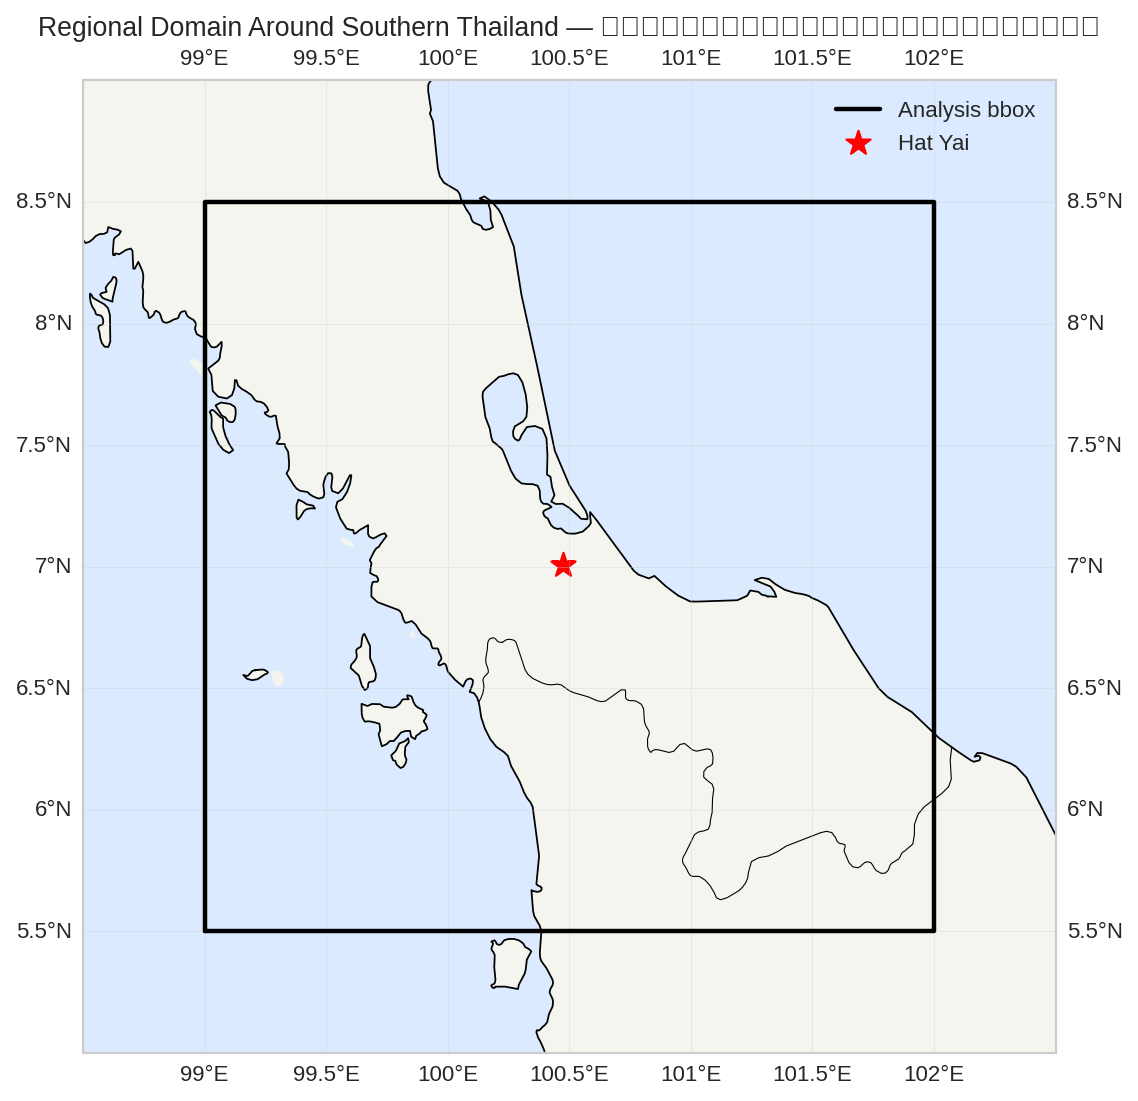

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดงขอบเขตพื้นที่ศึกษารอบหาดใหญ่และตำแหน่งเมืองหาดใหญ่ในภาคใต้ตอนล่าง จุดสำคัญคือการยืนยันว่า output จาก model ครอบคลุมพื้นที่ลุ่มน้ำและเมืองที่ต้องใช้ในการตัดสินใจ หากนำไปใช้จริงควรซ้อนทับแผนที่คลองหลัก พื้นที่ลุ่มต่ำ ถนน โรงพยาบาล และชุมชนเสี่ยงเพิ่มเติม

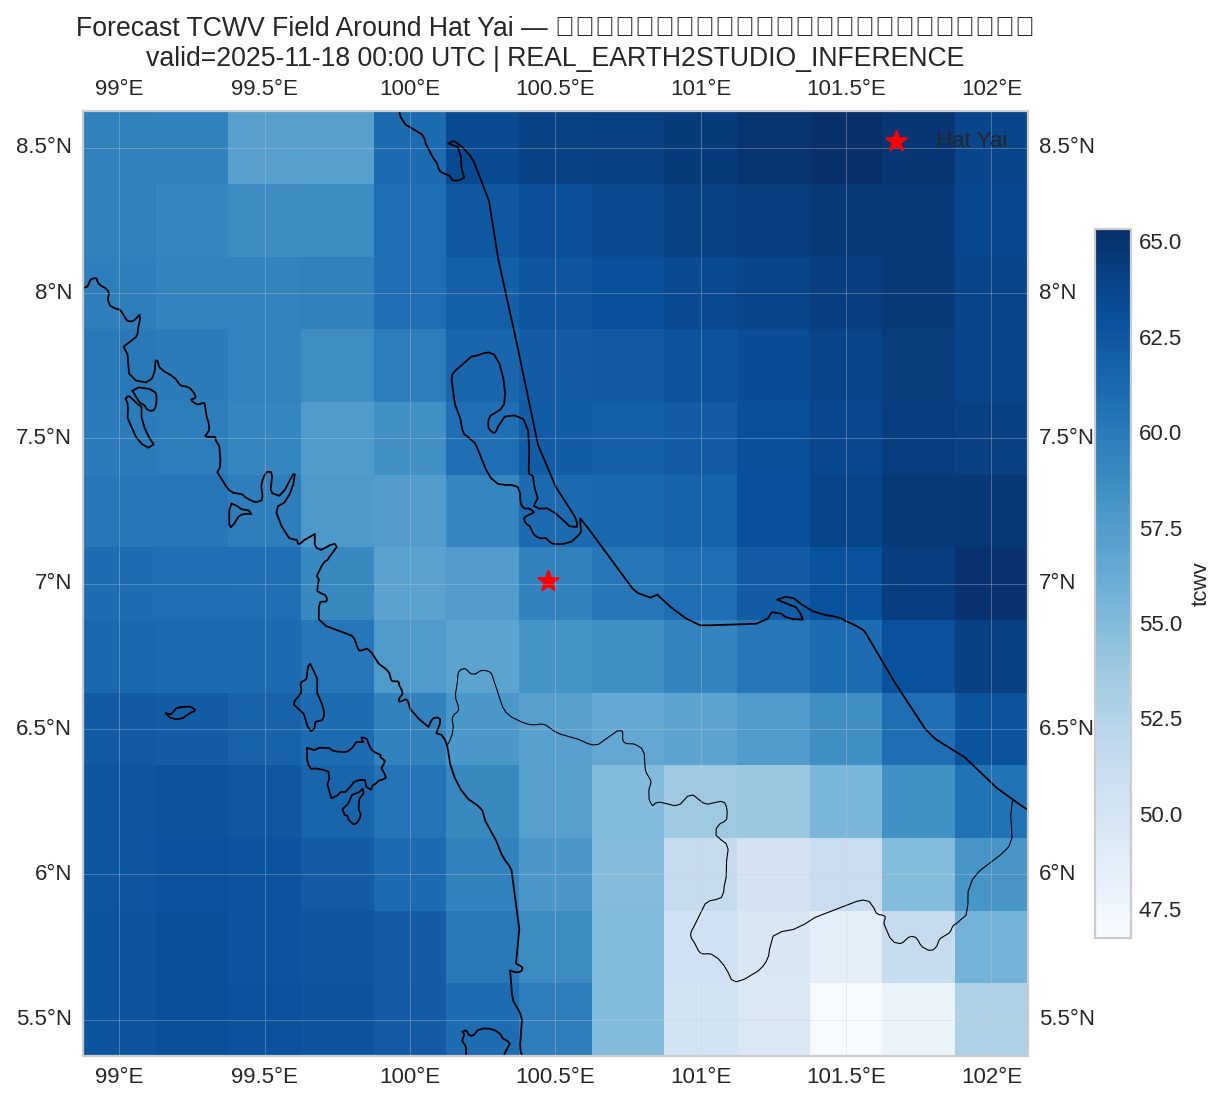

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้เป็นแผนที่ TCWV หรือไอน้ำรวมในบรรยากาศจาก forecast output รอบหาดใหญ่ ไม่ใช่ปริมาณฝนจริง แต่เป็นตัวชี้วัดว่าบรรยากาศมีความชื้นเพียงพอต่อฝนหนักหรือไม่ ใช้ประกอบการมองสัญญาณฝนสะสมร่วมกับลม ความกดอากาศ และข้อมูลฝนจริงจาก TMD/เรดาร์/ดาวเทียม

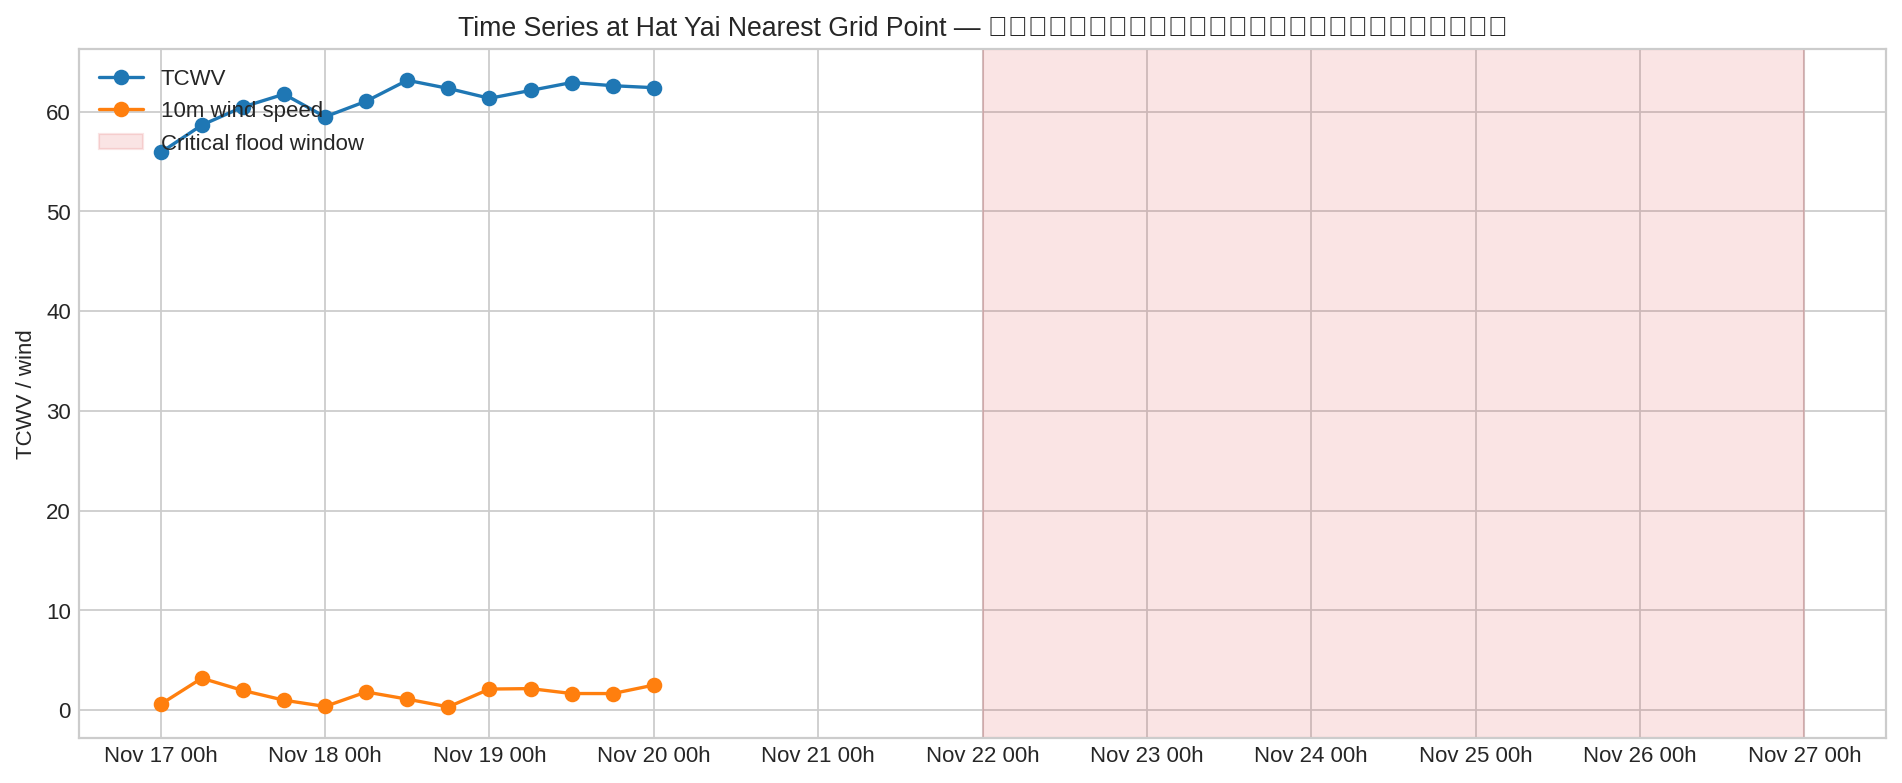

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดง time series ที่ grid point ใกล้หาดใหญ่ที่สุด ผู้บริหารควรดูแนวโน้มว่าความชื้นและลมเพิ่มขึ้นก่อนหรือระหว่างช่วงวิกฤตหรือไม่ ภาพนี้ช่วยให้เห็นว่าระบบสามารถแปลง output ของ model ให้เป็นสัญญาณติดตามรายเวลาในพื้นที่เป้าหมายได้

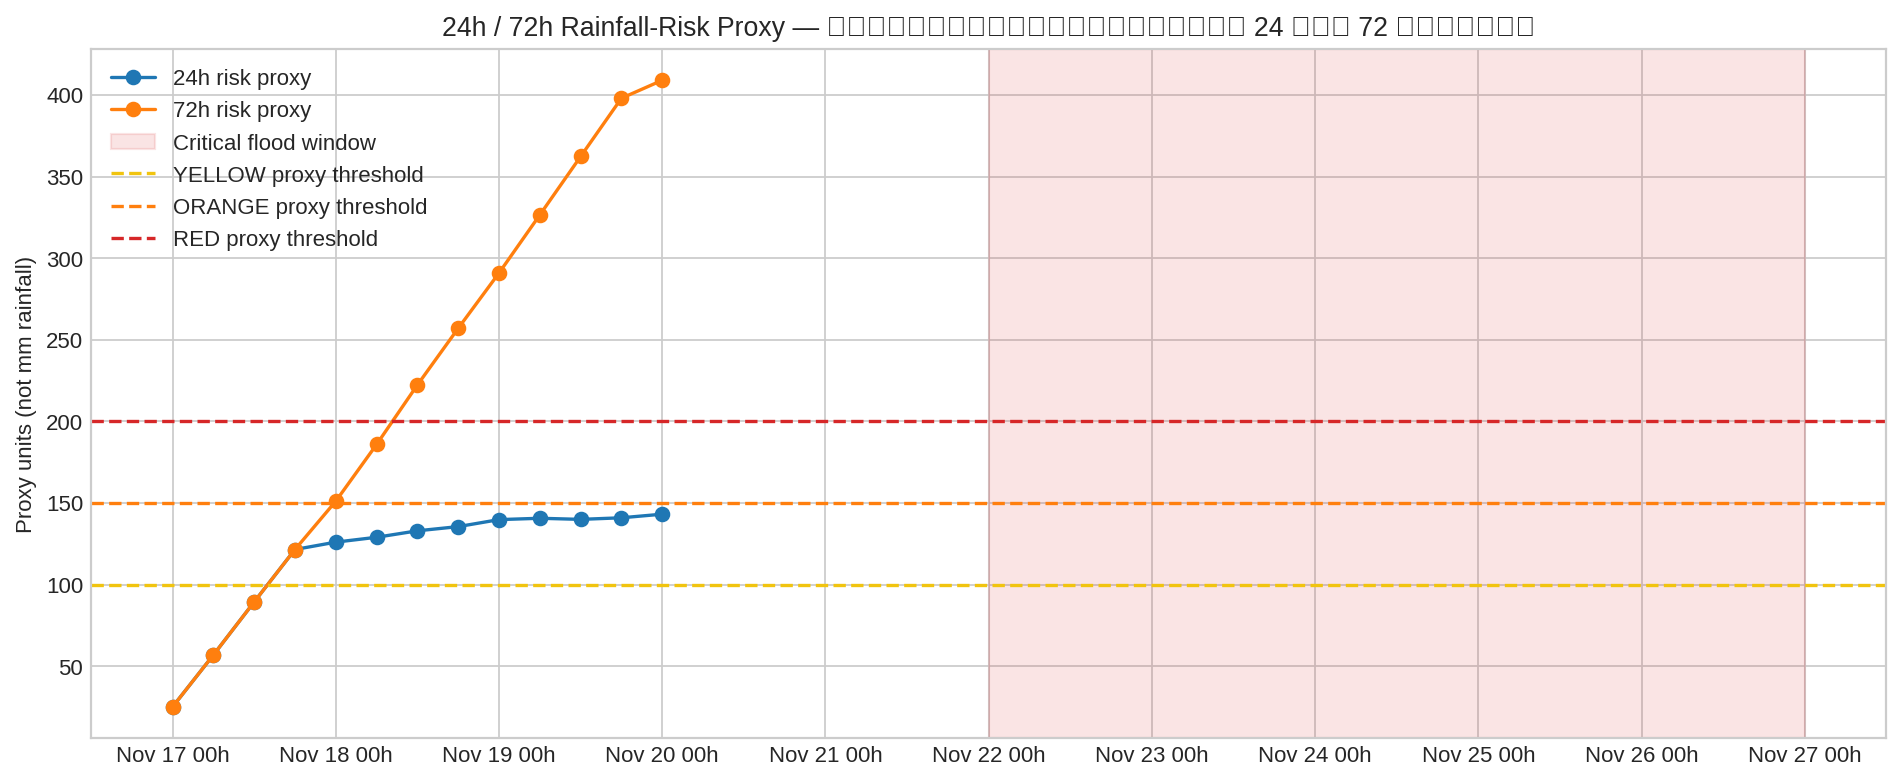

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดง 24h/72h rainfall-risk proxy ซึ่งคำนวณจากตัวแปร forecast จริง แต่ไม่ใช่ปริมาณฝนหน่วยมิลลิเมตรจริง จุดที่ควรจับตาคือช่วงที่ proxy เพิ่มขึ้นต่อเนื่องและข้ามเกณฑ์ YELLOW/ORANGE/RED เพราะเป็นจุดที่ระบบเตือนภัยควรเริ่มยกระดับการเฝ้าระวัง ไม่ควรรอให้เกิดน้ำท่วมแล้วจึงแจ้งเตือน

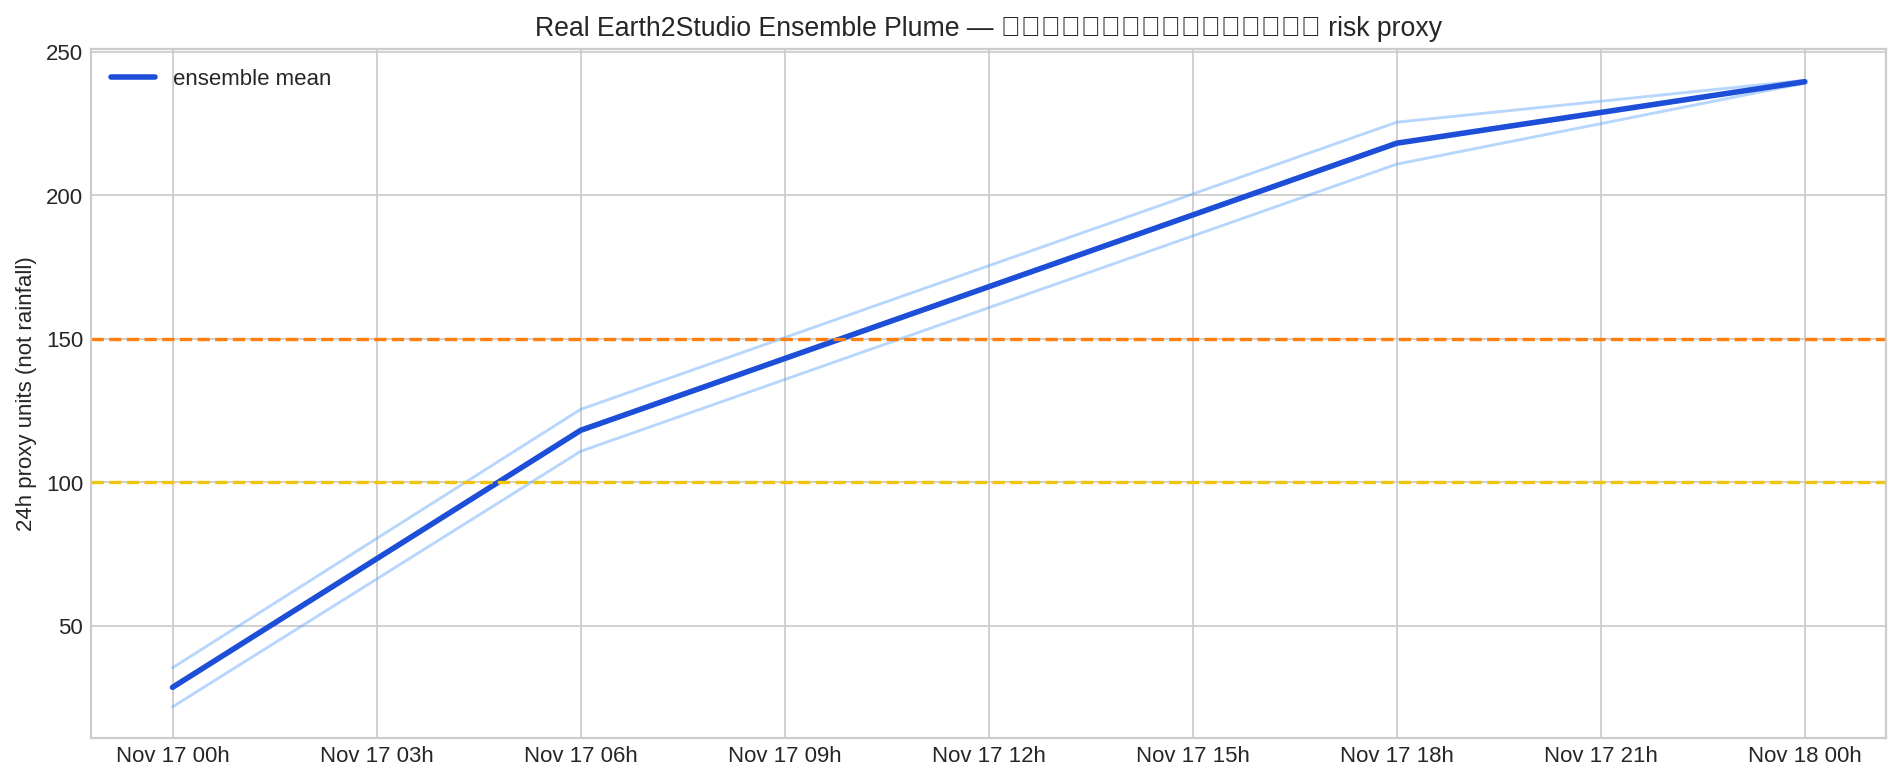

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดง ensemble plume เพื่อสื่อสารความไม่แน่นอนของ forecast ถ้าเส้นสมาชิกหลายเส้นขยับสูงพร้อมกัน ความมั่นใจเชิงระบบจะเพิ่มขึ้น แม้ตัวอย่างนี้ใช้ ensemble ขนาดเล็กเพื่อให้ notebook รันได้ แต่แนวคิดนี้สำคัญมากสำหรับระบบเตือนภัยจริงเพราะช่วยตัดสินใจจากความน่าจะเป็น ไม่ใช่จาก forecast เส้นเดียว

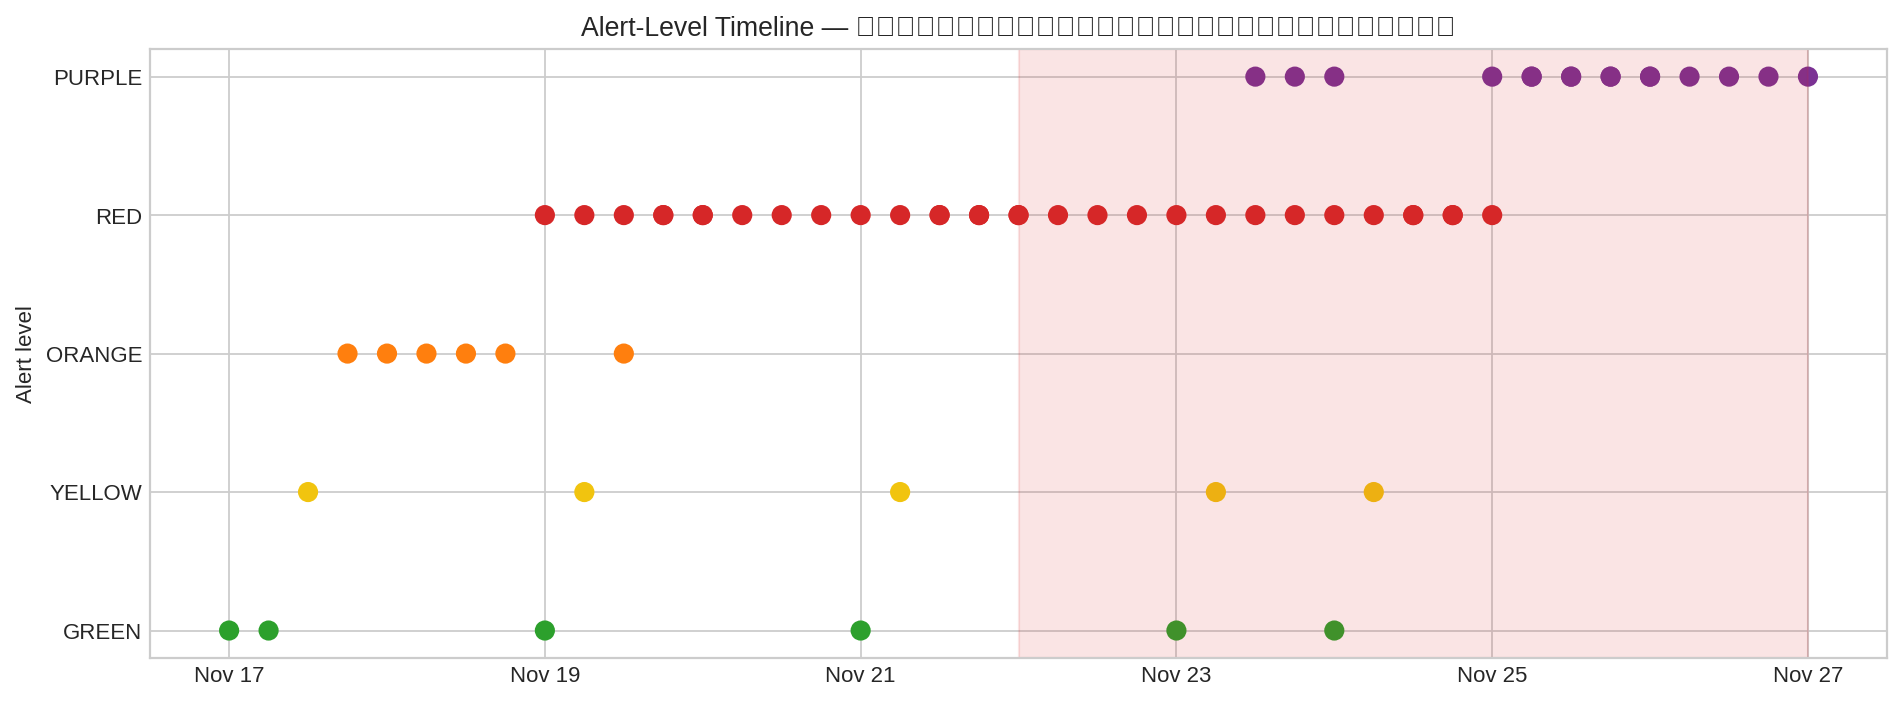

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดงเส้นเวลาการยกระดับคำเตือน GREEN/YELLOW/ORANGE/RED/PURPLE จาก output ของ forecast หรือ proxy จุดที่ต้องดูคือระบบเริ่มยกระดับเมื่อไรเมื่อเทียบกับช่วงวิกฤต ภาพนี้เหมาะสำหรับ discussion เรื่อง trigger, SOP, การเตรียมเครื่องสูบน้ำ เรือกู้ภัย ศูนย์พักพิง และการสื่อสารประชาชน

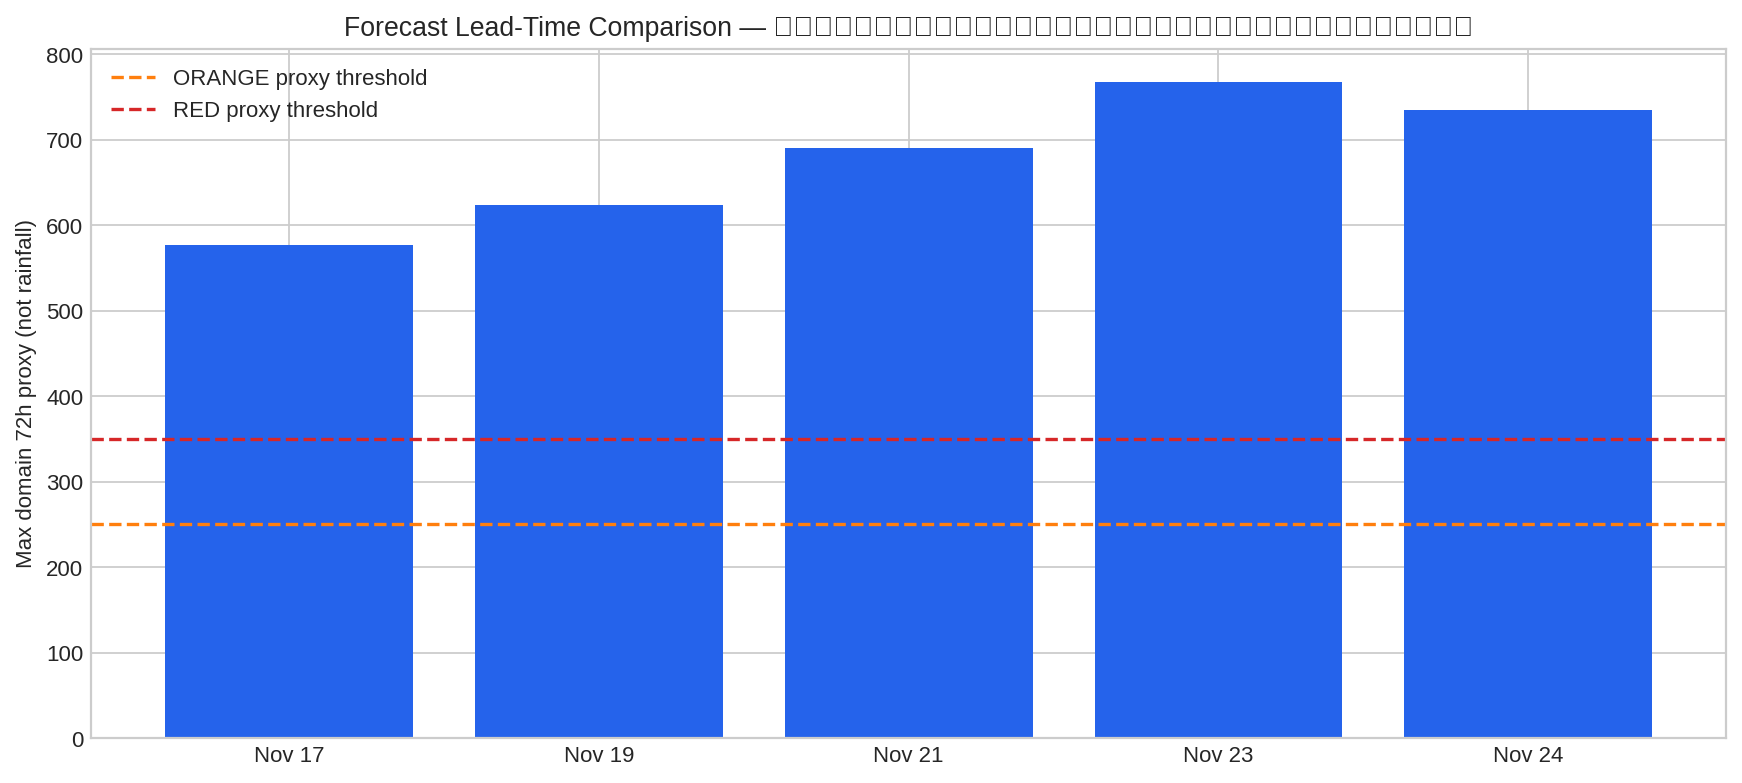

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้เปรียบเทียบสัญญาณจากแต่ละรอบพยากรณ์ initialization date เพื่อดูว่า warning lead time มีมากน้อยเพียงใด หากรอบพยากรณ์ก่อนวันวิกฤตเริ่มให้สัญญาณสูง ระบบปฏิบัติการจริงควรมีกระบวนการยืนยันและยกระดับคำเตือนล่วงหน้า

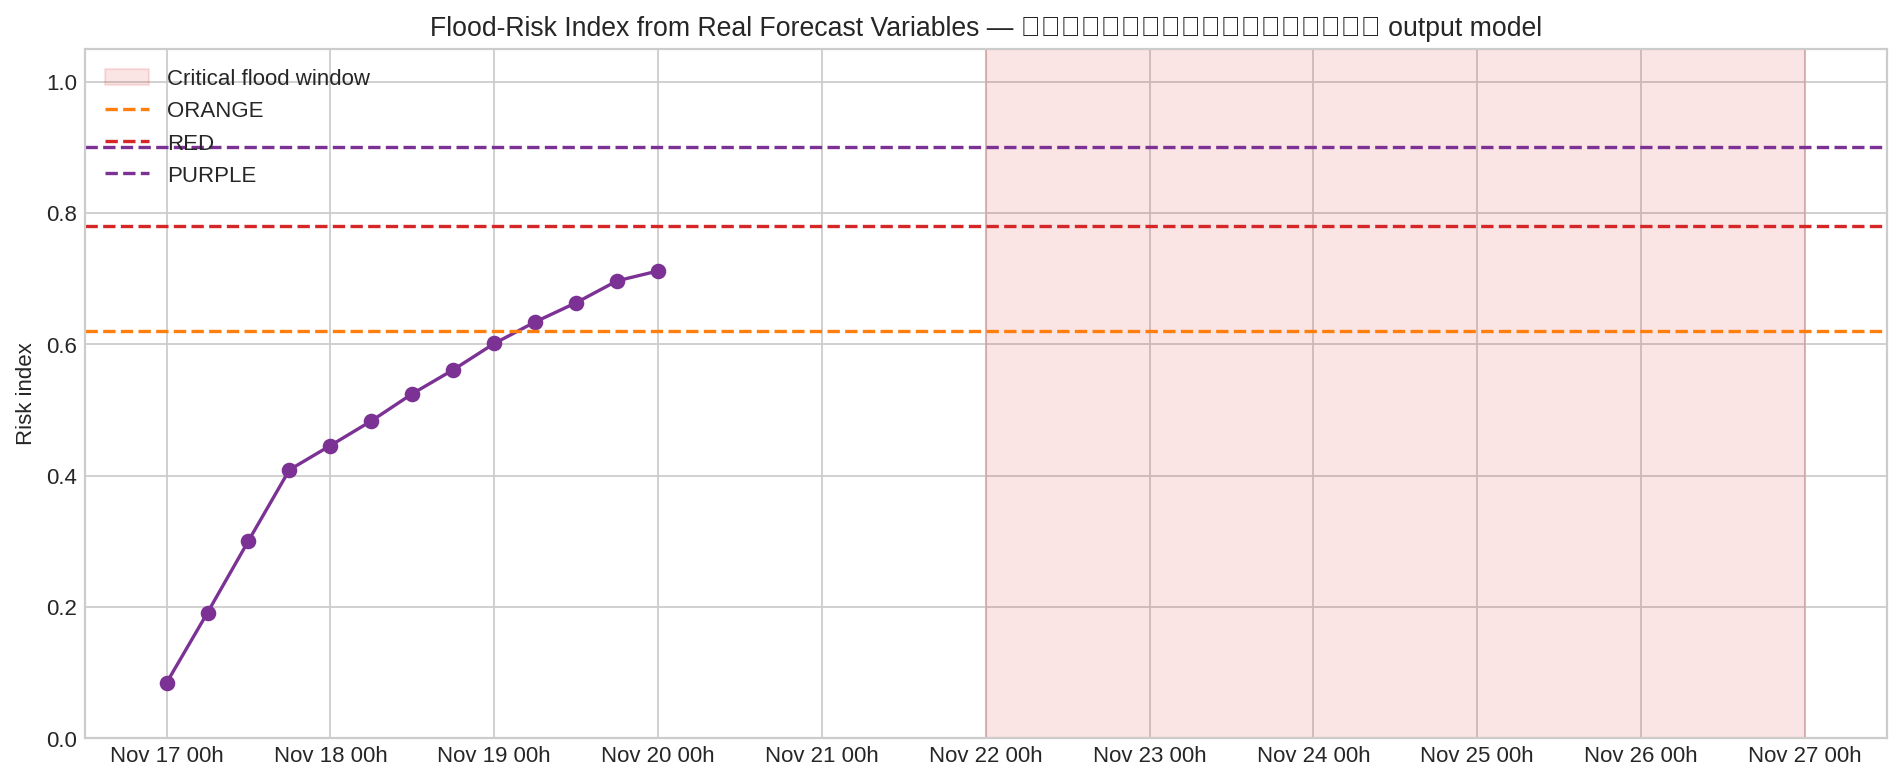

> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้เป็น flood-risk index จากตัวแปร forecast จริงและ proxy ไม่ใช่ระดับน้ำจริง จุดประสงค์คือแสดงชั้น decision-support ที่แปลงข้อมูลอากาศให้เป็นระดับความเสี่ยงที่ผู้บริหารอ่านได้ง่าย หากใช้งานจริงต้อง calibrate กับ rainfall gauge, water level, drainage capacity และประวัติน้ำท่วมจริง

Saved figures to: outputs/hatyai_flood_nov2025_real/figures


In [12]:
FIGURE_CAPTIONS_TH = {
    "01_regional_domain_map.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดงขอบเขตพื้นที่ศึกษารอบหาดใหญ่และตำแหน่งเมืองหาดใหญ่ในภาคใต้ตอนล่าง จุดสำคัญคือการยืนยันว่า output จาก model ครอบคลุมพื้นที่ลุ่มน้ำและเมืองที่ต้องใช้ในการตัดสินใจ หากนำไปใช้จริงควรซ้อนทับแผนที่คลองหลัก พื้นที่ลุ่มต่ำ ถนน โรงพยาบาล และชุมชนเสี่ยงเพิ่มเติม""",
    "02_forecast_tcwv_field_map.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้เป็นแผนที่ TCWV หรือไอน้ำรวมในบรรยากาศจาก forecast output รอบหาดใหญ่ ไม่ใช่ปริมาณฝนจริง แต่เป็นตัวชี้วัดว่าบรรยากาศมีความชื้นเพียงพอต่อฝนหนักหรือไม่ ใช้ประกอบการมองสัญญาณฝนสะสมร่วมกับลม ความกดอากาศ และข้อมูลฝนจริงจาก TMD/เรดาร์/ดาวเทียม""",
    "03_hatyai_point_timeseries.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดง time series ที่ grid point ใกล้หาดใหญ่ที่สุด ผู้บริหารควรดูแนวโน้มว่าความชื้นและลมเพิ่มขึ้นก่อนหรือระหว่างช่วงวิกฤตหรือไม่ ภาพนี้ช่วยให้เห็นว่าระบบสามารถแปลง output ของ model ให้เป็นสัญญาณติดตามรายเวลาในพื้นที่เป้าหมายได้""",
    "04_rainfall_risk_proxy_accumulation.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดง 24h/72h rainfall-risk proxy ซึ่งคำนวณจากตัวแปร forecast จริง แต่ไม่ใช่ปริมาณฝนหน่วยมิลลิเมตรจริง จุดที่ควรจับตาคือช่วงที่ proxy เพิ่มขึ้นต่อเนื่องและข้ามเกณฑ์ YELLOW/ORANGE/RED เพราะเป็นจุดที่ระบบเตือนภัยควรเริ่มยกระดับการเฝ้าระวัง ไม่ควรรอให้เกิดน้ำท่วมแล้วจึงแจ้งเตือน""",
    "05_real_ensemble_plume.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดง ensemble plume เพื่อสื่อสารความไม่แน่นอนของ forecast ถ้าเส้นสมาชิกหลายเส้นขยับสูงพร้อมกัน ความมั่นใจเชิงระบบจะเพิ่มขึ้น แม้ตัวอย่างนี้ใช้ ensemble ขนาดเล็กเพื่อให้ notebook รันได้ แต่แนวคิดนี้สำคัญมากสำหรับระบบเตือนภัยจริงเพราะช่วยตัดสินใจจากความน่าจะเป็น ไม่ใช่จาก forecast เส้นเดียว""",
    "06_alert_level_timeline.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้แสดงเส้นเวลาการยกระดับคำเตือน GREEN/YELLOW/ORANGE/RED/PURPLE จาก output ของ forecast หรือ proxy จุดที่ต้องดูคือระบบเริ่มยกระดับเมื่อไรเมื่อเทียบกับช่วงวิกฤต ภาพนี้เหมาะสำหรับ discussion เรื่อง trigger, SOP, การเตรียมเครื่องสูบน้ำ เรือกู้ภัย ศูนย์พักพิง และการสื่อสารประชาชน""",
    "07_forecast_lead_time_comparison.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้เปรียบเทียบสัญญาณจากแต่ละรอบพยากรณ์ initialization date เพื่อดูว่า warning lead time มีมากน้อยเพียงใด หากรอบพยากรณ์ก่อนวันวิกฤตเริ่มให้สัญญาณสูง ระบบปฏิบัติการจริงควรมีกระบวนการยืนยันและยกระดับคำเตือนล่วงหน้า""",
    "08_risk_index_timeline.png": """> **คำอธิบายสำหรับผู้บริหาร:**  
> ภาพนี้เป็น flood-risk index จากตัวแปร forecast จริงและ proxy ไม่ใช่ระดับน้ำจริง จุดประสงค์คือแสดงชั้น decision-support ที่แปลงข้อมูลอากาศให้เป็นระดับความเสี่ยงที่ผู้บริหารอ่านได้ง่าย หากใช้งานจริงต้อง calibrate กับ rainfall gauge, water level, drainage capacity และประวัติน้ำท่วมจริง""",
}

def savefig(name: str) -> Path:
    """Save current figure, then display the exported PNG artifact with a Thai executive caption."""
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=160, bbox_inches="tight")
    if Image is not None:
        display(Image(filename=str(path)))
    caption = FIGURE_CAPTIONS_TH.get(name)
    if caption:
        display(Markdown(caption))
    return path


def shade_critical(ax: Any) -> None:
    """Shade the critical Hat Yai flood window."""
    ax.axvspan(MAIN_ESCALATION_START, MAIN_ESCALATION_END, color="#d62728", alpha=0.12, label="Critical flood window")


def plot_domain_map() -> None:
    """Plot regional domain map around southern Thailand."""
    fig = plt.figure(figsize=(8, 7))
    if HAS_CARTOPY:
        ax = plt.axes(projection=ccrs.PlateCarree())
        ax.set_extent([98.5, 102.5, 5.0, 9.0], crs=ccrs.PlateCarree())
        ax.add_feature(cfeature.LAND, facecolor="#f5f5f0")
        ax.add_feature(cfeature.OCEAN, facecolor="#dbeafe")
        ax.coastlines(resolution="10m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    else:
        ax = plt.axes()
        ax.set_xlim(98.5, 102.5)
        ax.set_ylim(5.0, 9.0)
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    ax.plot([BBOX["lon_min"], BBOX["lon_max"], BBOX["lon_max"], BBOX["lon_min"], BBOX["lon_min"]],
            [BBOX["lat_min"], BBOX["lat_min"], BBOX["lat_max"], BBOX["lat_max"], BBOX["lat_min"]],
            color="black", linewidth=2, label="Analysis bbox")
    ax.scatter([CENTER_LON], [CENTER_LAT], color="red", marker="*", s=130, label="Hat Yai")
    ax.set_title("Regional Domain Around Southern Thailand — ขอบเขตพื้นที่ศึกษาหาดใหญ่")
    ax.legend(loc="upper right")
    savefig("01_regional_domain_map.png")


def plot_field_map(ds: xr.Dataset, variable: str, lead_hour: int, title: str, file_name: str, cmap: str = "viridis") -> None:
    """Plot a forecast field map."""
    lead_index = int(np.argmin(np.abs(pd.to_timedelta(ds["lead_time"].values).total_seconds() / 3600 - lead_hour)))
    field = ds[variable].isel(time=0, lead_time=lead_index)
    valid_time = valid_time_values(ds)[lead_index]
    fig = plt.figure(figsize=(9, 7))
    if HAS_CARTOPY:
        ax = plt.axes(projection=ccrs.PlateCarree())
        mesh = ax.pcolormesh(ds.lon, ds.lat, field, transform=ccrs.PlateCarree(), cmap=cmap, shading="auto")
        ax.coastlines(resolution="10m", linewidth=0.8)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.gridlines(draw_labels=True, linewidth=0.3, alpha=0.5)
    else:
        ax = plt.axes()
        mesh = ax.pcolormesh(ds.lon, ds.lat, field, cmap=cmap, shading="auto")
        ax.set_xlabel("Longitude")
        ax.set_ylabel("Latitude")
    ax.scatter([CENTER_LON], [CENTER_LAT], c="red", s=90, marker="*", label="Hat Yai")
    ax.set_title(f"{title}\nvalid={valid_time:%Y-%m-%d %H:%M UTC} | {INFERENCE_MODE}")
    ax.legend(loc="upper right")
    plt.colorbar(mesh, ax=ax, shrink=0.75, label=variable)
    savefig(file_name)


def point_dataframe(ds: xr.Dataset) -> pd.DataFrame:
    """Extract nearest Hat Yai point forecast as a DataFrame."""
    point = ds.sel(lat=CENTER_LAT, lon=CENTER_LON, method="nearest").isel(time=0)
    df = pd.DataFrame({"valid_time": valid_time_values(ds)})
    for var in ["t2m", "msl", "tcwv", "wind10m", "rainfall_risk_proxy_6h", "rainfall_risk_proxy_24h", "rainfall_risk_proxy_72h", "risk_index"]:
        if var in point:
            values = point[var].values
            df[var] = np.asarray(values).reshape(-1)
    if "t2m" in df:
        df["t2m_c"] = df["t2m"] - 273.15
    if "msl" in df:
        df["msl_hpa"] = np.where(df["msl"] > 2000, df["msl"] / 100.0, df["msl"])
    return df


def plot_point_timeseries(ds: xr.Dataset) -> None:
    """Plot time series at nearest Hat Yai grid point."""
    df = point_dataframe(ds)
    fig, ax1 = plt.subplots(figsize=(12, 5))
    ax1.plot(df["valid_time"], df["tcwv"], marker="o", label="TCWV")
    ax1.plot(df["valid_time"], df["wind10m"], marker="o", label="10m wind speed")
    shade_critical(ax1)
    ax1.set_ylabel("TCWV / wind")
    ax1.set_title("Time Series at Hat Yai Nearest Grid Point — สัญญาณพยากรณ์ที่จุดหาดใหญ่")
    ax1.legend(loc="upper left")
    ax1.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %Hh"))
    savefig("03_hatyai_point_timeseries.png")


def plot_proxy_accumulations(ds: xr.Dataset) -> None:
    """Plot 24h and 72h rainfall-risk proxy at Hat Yai."""
    df = point_dataframe(ds)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["valid_time"], df["rainfall_risk_proxy_24h"], marker="o", label="24h risk proxy")
    ax.plot(df["valid_time"], df["rainfall_risk_proxy_72h"], marker="o", label="72h risk proxy")
    shade_critical(ax)
    ax.axhline(100, color="#f1c40f", linestyle="--", label="YELLOW proxy threshold")
    ax.axhline(150, color="#ff7f0e", linestyle="--", label="ORANGE proxy threshold")
    ax.axhline(200, color="#d62728", linestyle="--", label="RED proxy threshold")
    ax.set_title("24h / 72h Rainfall-Risk Proxy — ดัชนีความเสี่ยงฝนสะสม 24 และ 72 ชั่วโมง")
    ax.set_ylabel("Proxy units (not mm rainfall)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %Hh"))
    savefig("04_rainfall_risk_proxy_accumulation.png")


def plot_ensemble_plume() -> None:
    """Plot real ensemble plume if ensemble output exists."""
    if ensemble_ds is None:
        print("No real ensemble dataset available; skipping ensemble plume.")
        return
    ens_point = ensemble_ds.sel(lat=CENTER_LAT, lon=CENTER_LON, method="nearest").isel(time=0)
    vt = valid_time_values(ensemble_ds)
    fig, ax = plt.subplots(figsize=(12, 5))
    for member in ensemble_ds["ensemble"].values:
        y = ens_point["rainfall_risk_proxy_24h"].sel(ensemble=member).values.reshape(-1)
        ax.plot(vt, y, color="#60a5fa", alpha=0.45, linewidth=1.3)
    mean_y = ens_point["rainfall_risk_proxy_24h"].mean(dim="ensemble").values.reshape(-1)
    ax.plot(vt, mean_y, color="#1d4ed8", linewidth=2.5, label="ensemble mean")
    ax.axhline(100, color="#f1c40f", linestyle="--")
    ax.axhline(150, color="#ff7f0e", linestyle="--")
    ax.set_title("Real Earth2Studio Ensemble Plume — ความไม่แน่นอนของ risk proxy")
    ax.set_ylabel("24h proxy units (not rainfall)")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %Hh"))
    savefig("05_real_ensemble_plume.png")


def plot_alert_timeline() -> None:
    """Plot alert-level timeline from forecast output."""
    fig, ax = plt.subplots(figsize=(12, 4.5))
    plot_df = alert_timeline.copy()
    plot_df["score"] = plot_df["recommended_alert_level"].map(ALERT_SCORE)
    plot_df["color"] = plot_df["recommended_alert_level"].map(ALERT_COLOR)
    ax.scatter(plot_df["valid_time"], plot_df["score"], c=plot_df["color"], s=65)
    shade_critical(ax)
    ax.set_yticks(range(len(ALERT_ORDER)), ALERT_ORDER)
    ax.set_title("Alert-Level Timeline — เส้นเวลาการยกระดับการแจ้งเตือน")
    ax.set_ylabel("Alert level")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d"))
    savefig("06_alert_level_timeline.png")


def plot_lead_time_comparison() -> None:
    """Plot forecast comparison across initialization dates."""
    fig, ax = plt.subplots(figsize=(11, 5))
    labels = pd.to_datetime(forecast_summary["init_time"]).dt.strftime("%b %d")
    ax.bar(labels, forecast_summary["max_domain_proxy_72h"], color="#2563eb")
    ax.axhline(250, color="#ff7f0e", linestyle="--", label="ORANGE proxy threshold")
    ax.axhline(350, color="#d62728", linestyle="--", label="RED proxy threshold")
    ax.set_title("Forecast Lead-Time Comparison — เปรียบเทียบสัญญาณจากแต่ละรอบพยากรณ์")
    ax.set_ylabel("Max domain 72h proxy (not rainfall)")
    ax.legend(loc="upper left")
    savefig("07_forecast_lead_time_comparison.png")


def plot_risk_index_timeline(ds: xr.Dataset) -> None:
    """Plot flood-risk index at Hat Yai point."""
    df = point_dataframe(ds)
    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(df["valid_time"], df["risk_index"], marker="o", color="#7b3294")
    shade_critical(ax)
    ax.axhline(0.62, color="#ff7f0e", linestyle="--", label="ORANGE")
    ax.axhline(0.78, color="#d62728", linestyle="--", label="RED")
    ax.axhline(0.90, color="#7b3294", linestyle="--", label="PURPLE")
    ax.set_ylim(0, 1.05)
    ax.set_title("Flood-Risk Index from Real Forecast Variables — ดัชนีความเสี่ยงจาก output model")
    ax.set_ylabel("Risk index")
    ax.legend(loc="upper left")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %d %Hh"))
    savefig("08_risk_index_timeline.png")


if HAS_MATPLOTLIB:
    plot_domain_map()
    plot_field_map(primary_derived, "tcwv", 24, "Forecast TCWV Field Around Hat Yai — แผนที่ไอน้ำรวมรอบหาดใหญ่", "02_forecast_tcwv_field_map.png", "Blues")
    plot_point_timeseries(primary_derived)
    plot_proxy_accumulations(primary_derived)
    plot_ensemble_plume()
    plot_alert_timeline()
    plot_lead_time_comparison()
    plot_risk_index_timeline(primary_derived)
    plt.close("all")

print("Saved figures to:", FIGURE_DIR)

## 13. Operational Interpretation / ความหมายเชิงปฏิบัติการ

### English
An operational flood early-warning system requires more than global AI weather inference. Earth2Studio can provide deterministic and ensemble weather signals, but production deployment must connect hydrology, local observations, exposure, and human approval.

### ภาษาไทย
Earth2Studio เป็นแกน AI weather inference ที่สำคัญ แต่ระบบเตือนภัยน้ำท่วมเมืองต้องมีข้อมูลและโมเดลท้องถิ่นเพิ่ม เช่น ฝนจริงจาก TMD/เรดาร์/ดาวเทียม ระดับน้ำ ThaiWater sensor คลอง U-Taphao คลอง R.1 ทางระบายลงทะเลสาบสงขลา DEM แผนที่ท่อระบายน้ำ พื้นที่ลุ่มต่ำ และ asset สำคัญ

> **สำหรับผู้บริหาร:**  
> ระบบจริงควรเป็น human-in-the-loop: AI ช่วยคำนวณความเสี่ยงและเสนอ alert level แต่การประกาศเตือนต้องผ่านหน่วยงานอุตุนิยมวิทยา อุทกวิทยา และป้องกันภัยที่มีอำนาจตามกฎหมาย

## 14. Final Executive Interpretation / สรุปเชิงบริหาร

### ภาษาไทย
**สิ่งที่ demo นี้พิสูจน์ได้**

Notebook นี้แสดงว่า workflow แบบ Earth2Studio สามารถโหลดข้อมูลอากาศ รัน AI weather inference บันทึก output อ่านผลกลับมา สร้างแผนที่/time series/table และแปลงผลเป็น alert-level logic สำหรับพื้นที่หาดใหญ่ได้อย่างเป็นขั้นตอน

**สิ่งที่ยังพิสูจน์ไม่ได้**

Notebook นี้ยังไม่ใช่ระบบเตือนภัยน้ำท่วมจริง เพราะยังไม่ได้เชื่อม rainfall observation, station/radar/satellite verification, water-level sensors, hydrological routing, drainage capacity, exposure map และ official approval workflow

**ข้อมูลที่ต้องเพิ่มเพื่อ deploy จริง**

- TMD rain gauge และ radar
- ThaiWater water-level sensors
- GPM IMERG / GSMaP / satellite rainfall
- DEM/topography และแผนที่ drainage network
- Khlong U-Taphao, Khlong R.1 และ Songkhla Lake drainage constraints
- historical flood maps และ impact reports
- critical assets เช่น โรงพยาบาล โรงเรียน ถนน ไฟฟ้า โทรคมนาคม ศูนย์พักพิง

**Recommended operational architecture**

Data ingestion -> Earth2Studio deterministic/ensemble forecast -> downscaling/radar nowcasting -> hydrological routing -> flood-risk model -> human approval -> public warning channels -> audit log

**Sovereign AI Flood Watchdog positioning**

SIAM.AI สามารถวางระบบนี้เป็นต้นแบบ Sovereign AI Flood Watchdog ของไทยได้ โดยให้ประเทศไทยควบคุม model workflow, data governance, GPU infrastructure, audit trail, และ decision-support layer เอง ขณะเดียวกันต้องทำงานร่วมกับหน่วยงานทางการเพื่อความถูกต้องและความชอบธรรมในการเตือนภัย

**Suggested next phase**

1. เชื่อมข้อมูลฝนย้อนหลังจริงของเหตุการณ์หาดใหญ่ พ.ศ. 2543, 2553, 2568
2. เชื่อมข้อมูลระดับน้ำและคลองสำคัญ
3. เพิ่ม hydrological routing และ drainage bottleneck model
4. Validate threshold กับ flood impacts จริง
5. สร้าง dashboard สำหรับ command center
6. กำหนด human-in-the-loop warning approval process

### English
This notebook demonstrates the technical feasibility of an AI-weather-based disaster replay pipeline. It does not yet validate an official flood forecast. The next phase should replace proxy signals with observed rainfall/water-level verification, add hydrology and exposure layers, and define an authorized warning workflow.

## 15. Run Metadata and Completion / Metadata และสถานะสุดท้าย

### English
The final cell writes run metadata, including data source, model, inference mode, output locations, errors, and safety notes.

### ภาษาไทย
ส่วนสุดท้ายบันทึก metadata เพื่อให้ตรวจสอบย้อนหลังได้ว่า notebook ใช้ data source อะไร model อะไร รันสำเร็จหรือไม่ อยู่ใน mode ใด และ output ถูกเก็บไว้ที่ไหน

> **สำหรับผู้บริหาร:**  
> ทุกระบบเตือนภัยจริงต้องมี audit trail: forecast รอบไหน, model version ใด, data source ใด, threshold ใด, ใครอนุมัติ และส่งคำเตือนผ่านช่องทางใด

In [ ]:
run_metadata = {
    "case": CASE_NAME,
    "mode": INFERENCE_MODE,
    "data_source_used": DATA_SOURCE_NAME,
    "model_used": MODEL_NAME,
    "real_inference_success": INFERENCE_MODE == "REAL_EARTH2STUDIO_INFERENCE",
    "real_ensemble_success": ensemble_ds is not None,
    "ensemble_error": ensemble_error,
    "n_steps": N_STEPS,
    "forecast_hours": int(N_STEPS * 6),
    "init_times_requested": [str(t) for t in INIT_TIMES],
    "init_times_run": [str(t) for t in RUN_INIT_TIMES],
    "forecast_outputs": [str(p) for p in deterministic_paths],
    "figures_dir": str(FIGURE_DIR),
    "tables_dir": str(TABLE_DIR),
    "data_source_errors": data_source_errors,
    "model_load_errors": model_load_errors,
    "real_inference_errors": real_inference_errors,
    "precipitation_note": "No direct precipitation in selected model output; rainfall-risk proxy used and clearly labeled.",
    "safety_note": "Research/demo only. Not an official life-safety warning system.",
}

(OUTPUT_DIR / "run_metadata.json").write_text(json.dumps(run_metadata, indent=2, ensure_ascii=False), encoding="utf-8")
print(json.dumps(run_metadata, indent=2, ensure_ascii=False))
print("Notebook completed successfully.")

{
  "case": "hatyai_flood_nov2025_real",
  "mode": "REAL_EARTH2STUDIO_INFERENCE",
  "data_source_used": "GFS",
  "model_used": "FCN3",
  "real_inference_success": true,
  "real_ensemble_success": true,
  "ensemble_error": null,
  "n_steps": 12,
  "forecast_hours": 72,
  "init_times_requested": [
    "2025-11-17 00:00:00",
    "2025-11-19 00:00:00",
    "2025-11-21 00:00:00",
    "2025-11-23 00:00:00",
    "2025-11-24 00:00:00"
  ],
  "init_times_run": [
    "2025-11-17 00:00:00",
    "2025-11-19 00:00:00",
    "2025-11-21 00:00:00",
    "2025-11-23 00:00:00",
    "2025-11-24 00:00:00"
  ],
  "forecast_outputs": [
    "outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025111700.zarr",
    "outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025111900.zarr",
    "outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025112100.zarr",
    "outputs/hatyai_flood_nov2025_real/forecast/deterministic_FCN3_GFS_2025112300.zarr",
    "outputs/hatyai_flo

: 